In [ ]:
# Listing 2.1 Calculating the median absolute deviation

import pandas as pd
import numpy as np
import statistics
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
 
def calc_MAD(data):
    median = statistics.median(data)
    deviations = [abs(x - median) for x in data]
    median_deviation = statistics.median(deviations)
    mad_scores = [abs(x - median) / median_deviation for x in data] 
    return mad_scores
    
data = fetch_openml("abalone", version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)
 
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))
 
pd.Series(data['Whole_weight']).hist(bins=50, ax=ax[0])
ax[0].set_title("Whole_weight")
 
mad_scores = calc_MAD(data['Whole_weight'])
pd.Series(mad_scores).hist(bins=50, ax=ax[1])
ax[1].set_title("Distribution of MAD Scores")
 
mad_scores = calc_MAD(np.concatenate([data['Whole_weight'], [4.0]]))
pd.Series(mad_scores).hist(bins=50, ax=ax[2])
ax[2].set_title("MAD Scores given an outlier")
 
plt.tight_layout()
plt.show()

In [ ]:
# Listing 2.2 Using histograms to identify outliers
# -------------------------------------------------

import pandas as pd
from sklearn.datasets import fetch_openml
import statistics
import matplotlib.pyplot as plt

# Collect the data
data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

# Create a histogram to represent one of the columns
histogram = pd.cut(data['hue-mean'], bins=10, retbins=True)[0]
# Get the count of values in each bin
counts = histogram.value_counts().sort_index()
print("count of values in each bin")
print(counts)
print("")

# Create a list of the bins with few values
rare_ranges = []
for v in counts.index:
    count = counts[v]
    if count < 10:
        rare_ranges.append(str(v))
print("list of the bins with few values")
print(rare_ranges)
print("")

# Create a list of the values in the bins with few values
rare_values = []
for i in range(len(data)):
    if str(histogram[i]) in rare_ranges:
        rare_values.append(data['hue-mean'][i])
print("list of the values in the bins with few values")
print(rare_values)
print("")

fig, ax = plt.subplots()
plt.hist(data['hue-mean'], bins=10, density=True)

# Draw a red vertical line at the position of each outlier
for rare_value in rare_values:
    ax.axvline(rare_value, color='red', linestyle='-.')
plt.xticks([statistics.mean([x.left, x.right]) for x in counts.index])
ax.set_xticklabels(range(10)) 
plt.show() 

In [ ]:
# Listing 2.3 Seaborn histplots with KDE enabled
# ----------------------------------------------

import pandas as pd
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
 
data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)
sns.histplot(data['hue-mean'], kde=True)
plt.show()

In [ ]:
# Listing 2.4 Using KDE to identify outliers
# ------------------------------------------

import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt

# Collect the data
data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

# Create a KDE estimate of one feature
X = data['hue-mean'].values.reshape(-1,1)
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X)
kde_scores = pd.Series(kde.score_samples(X))

# Calculate a threshold for KDE estimates using IQR
q1 = kde_scores.quantile(0.25)
q3 = kde_scores.quantile(0.75)
iqr = q3 - q1
threshold = q1 - (2.2 * iqr)
rare_values = [data['hue-mean'][x] for x in range(len(data)) 
               if kde_scores[x] < threshold]

# Draw the distribution of the data
fig, ax = plt.subplots()
plt.hist(data['hue-mean'], bins=200)

# Draw vertical lines at each point in a region with an unusually low KDE estimate
for rare_value in rare_values:
    ax.axvline(rare_value, color='red', linestyle='-.')
plt.show()

In [ ]:
# Listing 2.5 Using KNN to identify outliers
# ------------------------------------------

import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.neighbors import BallTree
 
data = fetch_openml('segment', version=1, parser='auto') 
data = pd.DataFrame(data.data, columns=data.feature_names)
X = data['hue-mean'].values.reshape(-1, 1)
tree = BallTree(X, leaf_size=2)              
dist, ind = tree.query(X, k=26)
max_dist_arr = pd.Series([max(x) for x in dist])


In [ ]:
# Listing 2.6 Determining the count threshold for outliers using cumulative counts
# --------------------------------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the data
data = fetch_openml('SpeedDating', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)
 
col_name = 'age_o'

# Fill null values
data[col_name] = \
    data[col_name].fillna(data[col_name].median()).astype(np.int64)

# Get the count of each unique value
vc = data[col_name].value_counts()
# Get the cumulative count of each unique value
cumm_frac = [vc.values[::-1][:x+1].sum() / len(data)
             for x in range(len(vc))]
cumm_frac = np.array(cumm_frac)
# Find the values with low cumulative counts
num_rare_vals = np.where(cumm_frac < 0.005)[0].max()
cut_off = vc.values[::-1][num_rare_vals]
min_count = vc[cut_off]
 
plt.subplots(figsize=(10, 2))
s= sns.barplot(x=vc.index, y=vc.values, order=vc.index, color='blue')
s.axvline(len(vc) - num_rare_vals - 0.5)
s.set_title(col_name)
plt.show()


In [ ]:
# Listing 2.7 Determining the counts for a pair of features
# ---------------------------------------------------------

from sklearn.datasets import fetch_openml
import pandas as pd
 
data = fetch_openml('eucalyptus', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names) 
print(data[['Abbrev', 'Locality', 'Sp']].value_counts())
 


In [ ]:
# Listing 2.8 Creating outlier scores per row using a set of univariate tests per feature
# ---------------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import statistics
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
 
def calc_MAD(data):
    median = statistics.median(data)
    deviations = [abs(x - median) for x in data]
    median_deviation = statistics.median(deviations)
    # Use the mean for features with median deviations of 0
    if median_deviation == 0:
        mean_deviation = statistics.mean(deviations)
        return [abs(x - median) / mean_deviation for x in data] 
    return [abs(x - median) / median_deviation for x in data] 

# Collect the data
data = fetch_openml('segment', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
 
total_mad_scores = [0]*len(df)
# Loop through each feature
for col_name in df.columns:
    if df[col_name].nunique() == 1:
        continue
    mad_scores = calc_MAD(df[col_name])
    mad_scores = np.array(mad_scores).reshape(-1, 1)
    # Scale the MAD scores for each feature to be between 0.0 and 1.0
    transformer = MinMaxScaler().fit(mad_scores)
    col_mad_scores = transformer.transform(mad_scores).reshape(1, -1)[0]
    total_mad_scores += col_mad_scores 
print(total_mad_scores)


In [ ]:
# Listing 3.1 Example of a KNN outlier detector implemented with the BallTree class
# ---------------------------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt
import seaborn as sns
 
np.random.seed(0)
n_per_cluster = 500

# Create first cluster
data_a = pd.Series(np.random.laplace(size= n_per_cluster))
data_b = pd.Series(np.random.laplace(size= n_per_cluster))
df1 = pd.DataFrame({"A": data_a, "B": data_b})

# Create second cluster
data_a = pd.Series(np.random.normal(loc=5, size=n_per_cluster))
data_b = pd.Series(np.random.normal(loc=15, size=n_per_cluster))
df2 = pd.DataFrame({"A": data_a, "B": data_b})
 
df = pd.concat([df1, df2])
 
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))
 
s = sns.scatterplot(data=df, x="A", y="B", alpha=0.4, ax=ax[0][0])

# Create a BallTree object representing the data
tree = BallTree(df, leaf_size=100)
dist, _ = tree.query(df, k=3)
dist = [x.mean() for x in dist]
df['Score'] = dist
s = sns.scatterplot(data=df, x="A", y="B", s=50*df['Score'], 
                    alpha=0.4, ax=ax[0][1])

# Find the top 5 outliers
cutoff = sorted(df['Score'])[-6]
df['Outlier'] = df['Score'] > cutoff
sns.scatterplot(data=df[df['Outlier']==False], x="A", y="B", 
                alpha=0.4, ax=ax[1][0])
sns.scatterplot(data=df[df['Outlier']==True], x="A", y="B", s=100,  
                alpha=1.0, marker='*', ax=ax[1][0])

# Find the top 15 outliers 
cutoff = sorted(df['Score'])[-16]
df['Outlier'] = df['Score'] > cutoff
sns.scatterplot(data=df[df['Outlier']==False], x="A", y="B", 
                alpha=0.4, ax=ax[1][1])
sns.scatterplot(data=df[df['Outlier']==True], x="A", y="B", s=100,         
                alpha=1.0, marker='*', ax=ax[1][1])
 
plt.show()


In [ ]:
# Listing 3.2 Radius Outler Detection
# -----------------------------------

tree = BallTree(df)
counts = tree.query_radius(df, 2.0, count_only=True)
 
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8, 4))

# Plot a histogram of the counts of records with different numbers of points within radius 2.0
s = sns.histplot(counts, ax=ax[0])
s.set_title(f"Number of Points within Radius")

# Reverse the scores so the more outlierish points have higher scores
min_score = min(counts)
max_score = max(counts)
scores = [(max_score - x)/(max_score - min_score) for x in counts]
s = sns.histplot(scores, ax=ax[1])
s.set_title(f"Scores")

# Plot the data highlighting the points with the 15 highest scores
df['Score'] = scores
threshold = sorted(scores, reverse=True)[15]    
df_flagged = df[df['Score'] >= threshold]
s = sns.scatterplot(data=df, x="A", y="B", ax=ax[2])
s = sns.scatterplot(data=df_flagged, x="A", y="B", color='red', 
                    marker='*', s=200, ax=ax[2])
 
plt.tight_layout()
plt.show()

In [ ]:
# Listing 3.3 Example of 2D KDE Plot
# ----------------------------------

import pandas as pd
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
 
data = fetch_openml('wall-robot-navigation', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)
 
sns.kdeplot(data=data_df, x="V6", y="V19", fill=True)
sns.scatterplot(data=data_df, x="V6", y="V19", alpha=0.2)
plt.show()


In [ ]:
# Listing 3.4 Using scikit-learn’s KernelDensity class for outlier detection
# --------------------------------------------------------------------------

from sklearn.neighbors import KernelDensity
 
X = data_df[['V6', 'V19']]
kde = KernelDensity(kernel='gaussian').fit(X)
log_density = kde.score_samples(X)
data_df['KDE Scores'] = -log_density
cutoff = sorted(data_df['KDE Scores'])[-30]
data_df['Outlier'] = data_df['KDE Scores'] > cutoff
 
sns.scatterplot(data=data_df[data_df['Outlier']==False], x="V6", y="V19",
                alpha=0.1)
sns.scatterplot(data=data_df[data_df['Outlier']==True], x="V6", y="V19",
                s=200, alpha=1.0, marker="*")
plt.show()

In [ ]:
# Listing 3.5 Using DBSCAN for outlier detection
# ----------------------------------------------

from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the data and select two features
data = fetch_openml('wall-robot-navigation', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)
X = data_df[['V6', 'V19']]

# Determine the cluster for all datapoints
clustering = DBSCAN().fit_predict(X)

# Take any points outside a cluster as an outlier
data_df['DBScan Outliers'] = np.where(clustering < 0, 1, 0)
sns.scatterplot(data=data_df[data_df['DBScan Outliers']==False], x="V6",
                y="V19", alpha=0.2, color='blue')
sns.scatterplot(data=data_df[data_df['DBScan Outliers']==True], x="V6", 
                y="V19", marker='*', s=200, color='red')
plt.show()

In [ ]:
pip install mlxtend

In [ ]:
# Listing 3.6 Executing FPOF outlier detection on the SpeedDating dataset
# -----------------------------------------------------------------------

from mlxtend.frequent_patterns import apriori
import pandas as pd
from sklearn.datasets import fetch_openml
import warnings
 
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

# Collect the data
data = fetch_openml('SpeedDating', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)

# Select a subset of the features
data_df = data_df[['d_pref_o_attractive', 'd_pref_o_sincere',
                   'd_pref_o_intelligence', 'd_pref_o_funny',
                   'd_pref_o_ambitious', 'd_pref_o_shared_interests']]

# Convert the data to binary format
data_df = pd.get_dummies(data_df)
for col_name in data_df.columns:
    data_df[col_name] = data_df[col_name].map({0: False, 1: True})

# Identify the frequent item sets
frequent_itemsets = apriori(data_df, min_support=0.3, use_colnames=True)
 
data_df['FPOF_Score'] = 0

# Loop through each FIS found in the data
for fis_idx in frequent_itemsets.index:
    fis = frequent_itemsets.loc[fis_idx, 'itemsets']
    # Find the support for the current FIS
    support = frequent_itemsets.loc[fis_idx, 'support']
    col_list = (list(fis))
    cond = True
    for col_name in col_list:
        cond = cond & (data_df[col_name])

    # Update the score for each record based on the support of each FIS it contains
    data_df.loc[data_df[cond].index, 'FPOF_Score'] += support

# Reverse the scores to have higher values for more outlierish records
min_score = data_df['FPOF_Score'].min()
max_score = data_df['FPOF_Score'].max()
data_df['FPOF_Score'] = [(max_score - x) / (max_score - min_score) 
                         for x in data_df['FPOF_Score']]

In [ ]:
# Listing 3.7 Predicting real vs. synthetic data
# ----------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_text
 
np.random.seed(0)

# Collect the data
data = load_breast_cancer()
data_df = pd.DataFrame(data.data, columns=data.feature_names)
data_df['Real'] = True

# Generate similar synthetic (fake) data
synth_df = pd.DataFrame()
for col_name in data_df.columns:
    mean = data_df[col_name].mean()
    stddev = data_df[col_name].std()
    synth_df[col_name] = np.random.normal(
       loc=mean, scale=stddev, size=len(data_df))
synth_df['Real'] = False
 
train_df = pd.concat([data_df, synth_df])

#Create a predictive model to distinguish the real from fake
clf = DecisionTreeClassifier(max_depth=7, random_state=0)
clf.fit(train_df.drop(columns=['Real']), train_df['Real'])
pred = clf.predict(train_df.drop(columns=['Real']))

# Output the accuracy of the model
confusion_matrix(train_df['Real'], pred)


In [ ]:
# Listing 4.1 Loading and examining the baseball dataset from OpenML
# ------------------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
data = fetch_openml('baseball', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.shape)
print(df.head())
print(df.dtypes)
 
for col_name in df.columns:
    if (df[col_name].dtype in ['int64', 'float64']):
        sns.histplot(data=df[col_name])
        plt.show()  

In [ ]:
sns.countplot(data=df, y='Position', orient='h', color='blue')
plt.show()  

In [ ]:
for col_idx_1, col_name_1 in enumerate(df.columns):
    for col_idx_2 in range(col_idx_1+1, len(df.columns)):
        col_name_2 = df.columns[col_idx_2]
        if (df[col_name_1].dtype in ['int64', 'float64']) and \
           (df[col_name_2].dtype in ['int64', 'float64']):
            sns.scatterplot(data=df, x=col_name_1, y=col_name_2)
            plt.show()
 

In [ ]:
for col_name_1 in df.columns:
    if (df[col_name_1].dtype in ['int64', 'float64']):
        sns.boxplot(data=df, x=col_name_1, y='Position', orient='h')
        plt.show()

In [ ]:
# Listing 5.1 Example using IsolationForest on the KDD Cup dataset
# ----------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
 
np.random.seed(0)
 
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                      return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)

# Encode the categorical columns
enc = OrdinalEncoder()
X = enc.fit_transform(X)

# Create and fit an IsolationForest detector
det = IsolationForest()
det.fit(X)

# Call predict() to get a binary prediction for each record
pred = pd.Series(det.predict(X))
pred = pred.map({1: 0, -1: 1})

# Evaluate the model using the labels in the dataset
print(confusion_matrix(y, pred))

# Call scores_samples() to get a numeric prediction for each record
pred = det.score_samples(X)
min_score = pred.min()
max_score = pred.max()
pred = [(x - min_score) / (max_score - min_score) for x in pred]
pred = [1.0 - x for x in pred]

# Evaluate again, using the numeric predictions
roc_auc_score(y, pred)


In [ ]:
# Listing 5.2 Example using LOF on the KDD Cup dataset (including tuning k)
# -------------------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
 
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42, 
                      return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)
 
cat_columns = ["protocol_type", "service", "flag"]
X_cat = pd.get_dummies(X[cat_columns])
col_names = [x.replace("'", '_') for x in X_cat.columns]
X_cat.columns = col_names
X_cat = X_cat.reset_index()
 L
numeric_cols = [x for x in X.columns if x not in cat_columns]
transformer = RobustScaler().fit(X[numeric_cols])
X_num = pd.DataFrame(transformer.transform(X[numeric_cols]))
X_num.columns = numeric_cols
X_num = X_num.reset_index()
 
X = pd.concat([X_cat, X_num], axis=1)
 
scores = []
for k in [5, 10, 20, 30, 40, 50, 60, 70, 80]:
    det = LocalOutlierFactor(n_neighbors=k)
    pred = det.fit_predict(X)
    pred = 1.0 - det.negative_outlier_factor_
    r = roc_auc_score(y, pred)
    scores.append(r)
    
s = sns.lineplot(x=[5, 10, 20, 30, 40, 50, 60, 70, 80], y=scores)
s.set_ylabel("AUROC Score")
s.set_xlabel("k")
plt.title("AUROC given k")
plt.ylim(0.0, 1.0)
plt.show() 



In [ ]:
import pandas as pd    
import numpy as np
from sklearn import svm
import matplotlib.pyplot as plt
# Define the range used for plotting 
min_range = -5
max_range = 5
xx, yy = np.meshgrid(np.linspace(min_range, max_range, 1000), 
                     np.linspace(min_range, max_range, 1000))

# Create the training data
x_data = np.random.normal(loc=2.0, scale=0.5, size=100)
y_data = np.random.normal(loc=2.0, scale=0.5, size=100)
cluster_1_df = pd.DataFrame(({'A': x_data, 'B': y_data}))
x_data = np.random.normal(loc=-2.0, scale=0.5, size=100)
y_data = np.random.normal(loc=-2.0, scale=0.5, size=100)
cluster_2_df = pd.DataFrame(({'A': x_data, 'B': y_data}))
X_train = pd.concat([cluster_1_df, cluster_2_df]).values

# Create test data similar to the training data
x_data = np.random.normal(loc=2.0, scale=0.4, size=20)
y_data = np.random.normal(loc=2.0, scale=0.4, size=20)
X_test_normal = pd.DataFrame(({'A': x_data, 'B': y_data})).values

# Create test data unlike the training data
x_data = np.random.normal(loc=0.0, scale=4.0, size=20)
y_data = np.random.normal(loc=0.0, scale=4.0, size=20)
X_test_outliers = pd.DataFrame(({'A': x_data, 'B': y_data})).values

# Create and fit a OCSVM detector
clf = svm.OneClassSVM(nu=0.1)
clf.fit(X_train)

# Predict for the train and test data
y_pred_train     = clf.predict(X_train)
y_pred_normal    = clf.predict(X_test_normal)
y_pred_outliers  = clf.predict(X_test_outliers)
n_error_train    = y_pred_train.tolist().count(-1)
n_error_normal   = y_pred_normal.tolist().count(-1)
n_error_outliers = y_pred_outliers.tolist().count(-1)
 
dec_func = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
dec_func = dec_func.reshape(xx.shape)

# Plot the data and the decision boundary
plt.title("OCSVM")
plt.contourf(xx, yy, dec_func, 
             levels=np.linspace(dec_func.min(), 0, 7), cmap=plt.cm.PuBu)
a = plt.contour(xx, yy, dec_func, levels=[0], linewidths=2, colors="red")
plt.contourf(xx, yy, dec_func, levels=[0, dec_func.max()], colors="green")
 
train_points = plt.scatter(X_train[:, 0], X_train[:, 1], 
                           c="grey", s=40, marker='.')
normal_points = plt.scatter(X_test_normal[:, 0], X_test_normal[:, 1], 
                            c="blue", s=50, marker="*")
outlier_points = plt.scatter(X_test_outliers[:, 0], X_test_outliers[:, 1], 
                             c="red", s=50, marker='P')
 
plt.axis("tight")
plt.xlim((min_range, max_range))
plt.ylim((min_range, max_range))
plt.legend(
    [a.collections[0], train_points, normal_points, outlier_points],
    ["Decision Boundary", "Training data", "Subsequent normal points",
        "Subsequent outlier points"],
    bbox_to_anchor = (1.6, 0.6),
    loc="center right",
)
plt.xlabel(
    (f"Errors in training: {n_error_train}/200\n"
     f"Errors novel normal: {n_error_normal}/20\n"
     f"Errors novel outlier: {n_error_outliers}/20"))
plt.show()

In [ ]:
# Listing 5.4 Using OneClassSVM on the KDD Cup dataset
# ----------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import roc_auc_score
 
X, y = fetch_kddcup99(
    subset="SA",  percent10=True, 
    random_state=42, return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)

# Encode the categorical columns
cat_columns = ["protocol_type", "service", "flag"]
X_cat = pd.get_dummies(X[cat_columns])
col_names = [x.replace("'", '_') for x in X_cat.columns]
X_cat.columns = col_names
X_cat = X_cat.reset_index()

# Scale the numeric columns
num_cols = [x for x in X.columns if x not in cat_columns]
transformer = RobustScaler().fit(X[num_cols])
X_num = pd.DataFrame(transformer.transform(X[num_cols]))
X_num.columns = num_cols
X_num = X_num.reset_index()
 
X = pd.concat([X_cat, X_num], axis=1)

# Split the data into train and test portions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.90, random_state=42)
# Find the normal examples in the train in the y feature
y_train = y_train[y_train == 0]
# Use the same subset of records (the normal records) for the X features as for the y feature
X_train = X_train.loc[y_train.index]

# Create and fit a OCSVM detector on the normal train data
det = OneClassSVM()
det.fit(X_train)

# Evaluate the model on the test data
pred = det.score_samples(X_test)
min_score = pred.min()
max_score = pred.max()
pred = [(x - min_score) / (max_score - min_score) for x in pred]
pred = [1.0 - x for x in pred]
roc_auc_score(y_test, pred) 


In [ ]:
# Listing 5.5 Example using SGDOneClassSVM with a kernel approximation
# --------------------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.pipeline import make_pipeline

X, y = fetch_kddcup99(
    subset="SA",  percent10=True, 
    random_state=42, return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)

# Encode the categorical columns
cat_columns = ["protocol_type", "service", "flag"]
X_cat = pd.get_dummies(X[cat_columns])
col_names = [x.replace("'", '_') for x in X_cat.columns]
X_cat.columns = col_names
X_cat = X_cat.reset_index()

# Scale the numeric columns
num_cols = [x for x in X.columns if x not in cat_columns]
transformer = RobustScaler().fit(X[num_cols])
X_num = pd.DataFrame(transformer.transform(X[num_cols]))
X_num.columns = num_cols
X_num = X_num.reset_index()
 
X = pd.concat([X_cat, X_num], axis=1)

# Split the data into train and test portions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.90, random_state=42)
# Find the normal examples in the train in the y feature
y_train = y_train[y_train == 0]
# Use the same subset of records (the normal records) for the X features as for the y feature
X_train = X_train.loc[y_train.index]

# Create and fit a OCSVM detector on the normal train data
det = OneClassSVM()
det.fit(X_train)

# # Create and fit a SGDOneClassSVM detector on the normal train data
transform = Nystroem(random_state=42)
clf_sgd = SGDOneClassSVM()
pipe_sgd = make_pipeline(transform, clf_sgd)
pipe_sgd.fit(X_train)
pred = pipe_sgd.score_samples(X_test)

# Evaluate the model on the test data
pred = det.score_samples(X_test)
min_score = pred.min()
max_score = pred.max()
pred = [(x - min_score) / (max_score - min_score) for x in pred]
pred = [1.0 - x for x in pred]
roc_auc_score(y_test, pred) 


In [ ]:
# Listing 5.6 Example using Minimum Covariance Determinant
# --------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.covariance import MinCovDet
 
np.random.seed(0)
a_data = np.random.laplace(size=1000)
b_data = np.random.normal(size=1000) + a_data
c_data = np.random.exponential(size=1000) + a_data + b_data
X = pd.DataFrame({"A": a_data, "B": b_data, "C": c_data})
 
cov = MinCovDet(random_state=0).fit(X)
3print(cov.covariance_)

In [ ]:
# Listing 5.8 Example of the EllipticEnvelope detector with the mfeat-karhunen dataset
# ------------------------------------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the data from OpenML
data = fetch_openml('mfeat-karhunen', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)

# Create and fit an EllipticEnvelope detector
cov = EllipticEnvelope(random_state=0).fit(df[['att6', 'att7']])
pred = cov.predict(df[['att6', 'att7']])
 
df['Elliptic Score'] = pred

# Plot the results
df['Elliptic Score'] = df['Elliptic Score'].map({-1: 1, 1: 0})
sns.scatterplot(data=df[df['Elliptic Score']==0], x="att6", y='att7',
                alpha=0.3) 
sns.scatterplot(data=df[df['Elliptic Score']==1], x="att6", y='att7',
                alpha=1.0, s=200, marker='*') 
plt.show()

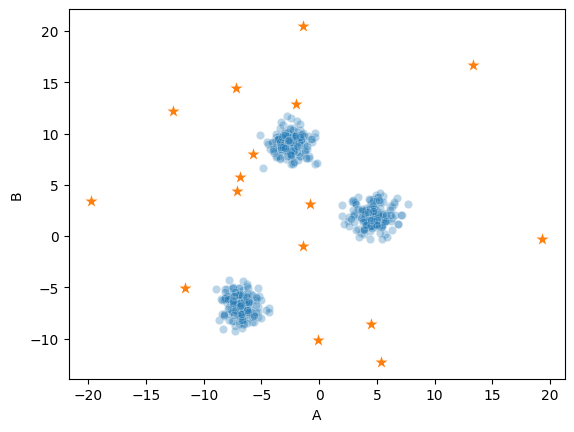

In [10]:
# Listing 5.9 Example of Gaussian Mixture Models for outlier detection
# --------------------------------------------------------------------

from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy import stats
 
np.random.seed(0)

# Create synthetic data
vals, _ = make_blobs(n_samples=500, centers=3, n_features=2, 
                     cluster_std=1, random_state=42)         
df_inliers = pd.DataFrame(vals, columns=["A", "B"])
 
vals, _ = make_blobs(n_samples=15, centers=2, n_features=2, 
                     cluster_std=10, random_state=42)
df_outliers = pd.DataFrame(vals, columns=["A", "B"])
 
df = pd.concat([df_inliers, df_outliers])
X = df[['A', 'B']]

# Create a set of GMMs with a range of values for n_components
best_n_components = -1
best_bic = np.inf
for n_components in range(1, 8):
    gmm = GaussianMixture(n_components=n_components, n_init=5,
                          random_state=42)  
    gmm.fit(X)    
    bic = gmm.bic(X)
    if bic < best_bic:
        best_bic = bic
        best_n_components = n_components

# Create a final GMM using the best n_components
gmm = GaussianMixture(n_components=best_n_components, 
                      n_init=5, random_state=42)
gmm.fit(X)    
 
score = gmm.score_samples(X)
df['Score'] = score

# Set a threshold on the scores to support plotting
pct_threshold = np.percentile(score, 3.0)
df['Outlier'] = df['Score'] < pct_threshold
 
sns.scatterplot(data=df[df['Outlier'] == False], x='A', y='B', alpha=0.3) 
sns.scatterplot(data=df[df['Outlier'] == True], x='A', y='B', 
                s=150, marker='*')
plt.show()


In [ ]:
pip install pyod

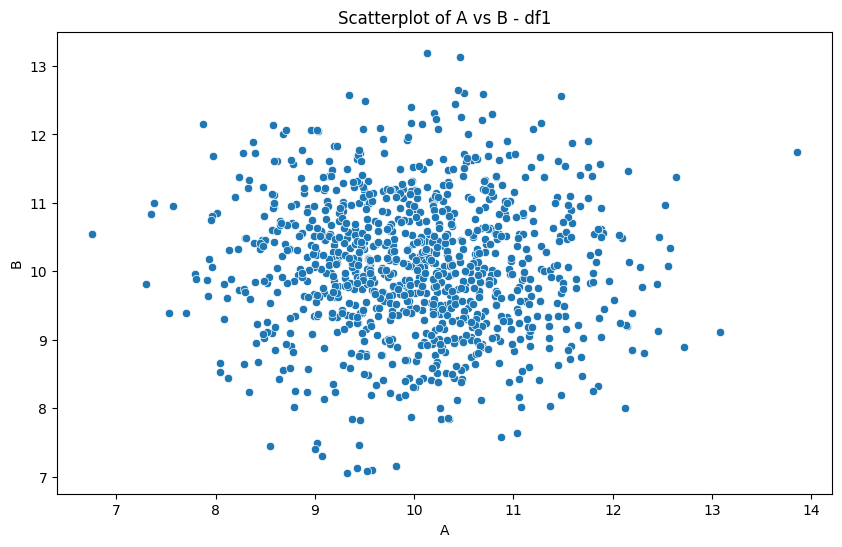

           A          B  Ground Truth
0  10.496714  11.399355             0
1   9.861736  10.924634             0
2  10.647689  10.059630             0
3  11.523030   9.353063             0
4   9.765847  10.698223             0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   A             1000 non-null   float64
 1   B             1000 non-null   float64
 2   Ground Truth  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None

                 A            B  Ground Truth
count  1000.000000  1000.000000        1000.0
mean     10.019332    10.070836           0.0
std       0.979216     0.997454           0.0
min       6.758733     7.059611           0.0
25%       9.352410     9.393758           0.0
50%      10.025301    10.063077           0.0
75%      10.647944    10.728882           0.0
max      13.852731    13.1

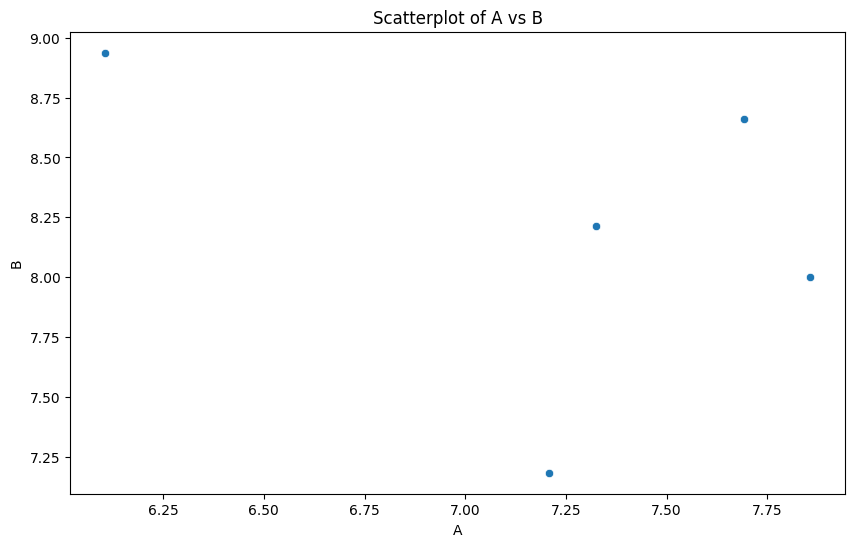

          A         B  Ground Truth
0  7.324822  8.213294             1
1  7.855481  8.001205             1
2  7.207580  7.182911             1
3  7.692038  8.659246             1
4  6.106385  8.937570             1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   A             5 non-null      float64
 1   B             5 non-null      float64
 2   Ground Truth  5 non-null      int64  
dtypes: float64(2), int64(1)
memory usage: 252.0 bytes
None

              A         B  Ground Truth
count  5.000000  5.000000           5.0
mean   7.237261  8.198845           1.0
std    0.684917  0.676216           0.0
min    6.106385  7.182911           1.0
25%    7.207580  8.001205           1.0
50%    7.324822  8.213294           1.0
75%    7.692038  8.659246           1.0
max    7.855481  8.937570           1.0

scaled

          A         B  Ground Truth
0 

In [25]:
# inspect data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Create normal data
x_data = np.random.normal(loc=10, scale=1.0, size=1000)
y_data = np.random.normal(loc=10, scale=1.0, size=1000)
df1 = pd.DataFrame({'A': x_data, 'B':y_data})

# plot points
# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='A', y='B')
plt.title('Scatterplot of A vs B - df1')
plt.xlabel('A')
plt.ylabel('B')
plt.show()

df1['Ground Truth'] = 0

# inspect data
print(df1.head())
print("")
print(df1.info())
print("")
print(df1.describe())

# scale
df1 = pd.DataFrame(RobustScaler().fit_transform(df1), columns=df1.columns)
print("")
print("scaled")
print("")
print(df1.head())
print("")
print(df1.info())
print("")
print(df1.describe())
print("")
print("-------------------------------")
print("")
# Create outliers around the edge of the normal data
x_data = np.random.normal(loc=8, scale=1.0, size=5)
y_data = np.random.normal(loc=8, scale=1.0, size=5)
df2 = pd.DataFrame({'A': x_data, 'B':y_data})

# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df2, x='A', y='B')
plt.title('Scatterplot of A vs B')
plt.xlabel('A')
plt.ylabel('B')
plt.show()

df2['Ground Truth'] = 1

# inspect data
print(df2.head())
print("")
print(df2.info())
print("")
print(df2.describe())

# scale
df2 = pd.DataFrame(RobustScaler().fit_transform(df1), columns=df2.columns)
print("")
print("scaled")
print("")
print(df2.head())
print("")
print(df2.info())
print("")
print(df2.describe())
print("")
print("-------------------------------")
print("")



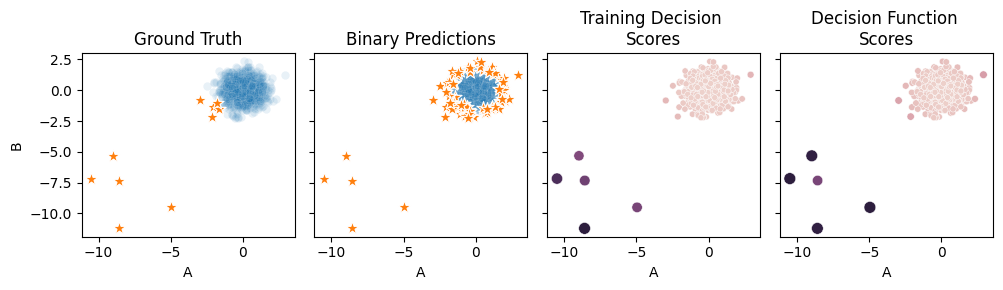

In [14]:
# Listing 6.3 Example of the standard PyOD API using KNN
# ------------------------------------------------------

import pandas as pd
import numpy as np
from pyod.models.knn import KNN
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
 
np.random.seed(42)

# Create normal data
x_data = np.random.normal(loc=10, scale=1.0, size=1000)
y_data = np.random.normal(loc=10, scale=1.0, size=1000)
df1 = pd.DataFrame({'A': x_data, 'B':y_data})
df1['Ground Truth'] = 0

# Create outliers around the edge of the normal data
x_data = np.random.normal(loc=8, scale=1.0, size=5)
y_data = np.random.normal(loc=8, scale=1.0, size=5)
df2 = pd.DataFrame({'A': x_data, 'B':y_data})
df2['Ground Truth'] = 1

# Create outliers outside the normal data
x_data = np.random.normal(loc=1, scale=3.0, size=5)
y_data = np.random.normal(loc=1, scale=3.0, size=5)
df3 = pd.DataFrame({'A': x_data, 'B':y_data})
df3['Ground Truth'] = 1
 
df = pd.concat([df1, df2, df3])
df = df.reset_index()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
 
fig, ax = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(10, 3)) 

# Plot the ground truth
sns.scatterplot(data=df[df['Ground Truth'] == False], x='A', y='B',        
                alpha=0.1, ax=ax[0])
s = sns.scatterplot(data=df[df['Ground Truth'] == True], x='A', y='B', 
                    alpha=1.0, s=100, marker='*', ax=ax[0]) 
s.set_title('Ground Truth')

# Fit the model to the data
clf = KNN()
clf.fit(df[['A', 'B']])

# Plot the predictions
df['KNN Binary Prediction'] = clf.predict(df[['A', 'B']])
sns.scatterplot(data=df[df['KNN Binary Prediction'] == False], x='A',   
                y='B', alpha=0.1, ax=ax[1]) 
s = sns.scatterplot(data=df[df['KNN Binary Prediction'] == True], x='A', 
                    y='B', alpha=1.0, s=100, marker='*', ax=ax[1]) 
s.set_title('Binary Predictions')
 
df['KNN Decision Scores'] = clf.decision_scores_
s = sns.scatterplot(data=df, x='A', y='B', hue='KNN Decision Scores', 
                    size='KNN Decision Scores', ax=ax[2])
s.get_legend().remove()
s.set_title('Training Decision \nScores')
 
df['KNN Decision Function'] = clf.decision_function(df[['A', 'B']])
s = sns.scatterplot(data=df, x='A', y='B', hue='KNN Decision Function', 
                    size='KNN Decision Function', ax=ax[3])
s.get_legend().remove()
s.set_title('Decision Function \nScores')
 
plt.tight_layout()
plt.show()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V391,V392,V393,V394,V395,V396,V397,V398,V399,V400
0,-0.35069,0.52721,-1.62470,-1.334000,-1.03020,1.24750,-0.98067,-1.55870,-0.061233,1.048200,...,0.437720,0.570960,-1.19840,2.168600,-0.30353,1.21620,-0.607070,0.503820,-0.45571,0.86283
1,-0.42537,-0.08818,0.84575,0.881570,1.35690,0.74894,-1.68620,0.46151,0.585700,0.775950,...,-0.016239,-0.582980,-0.35666,-0.638000,0.64106,-0.94488,-1.069700,-0.024029,0.28696,-0.12374
2,-1.22100,0.43960,-0.06303,0.709530,0.95079,-0.21874,-1.24850,-1.62860,-1.339700,-1.858500,...,1.985500,-0.042742,2.77110,1.549400,-1.75680,-0.91595,-0.078469,0.097137,-0.55111,0.69951
3,-0.30132,0.55221,0.13769,0.715290,0.99311,-0.16959,-0.93405,-0.94825,-0.750880,0.003107,...,1.172300,-0.103520,2.53710,2.096000,-1.43680,-1.05230,-0.070276,-0.539810,-1.10380,0.70562
4,0.31292,0.42762,0.50348,0.005489,-0.94274,-0.17619,-0.50775,-0.46445,0.694750,0.376040,...,-1.317400,1.060700,1.39660,0.096776,-1.18360,-0.37802,0.357150,1.278600,-0.40139,0.11640


C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


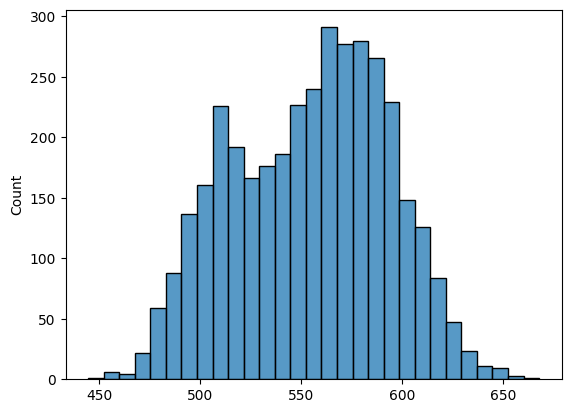

In [2]:
# Listing 6.4 Using HBOS with the speech dataset
# ----------------------------------------------

import pandas as pd
from pyod.models.hbos import HBOS
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
 
data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
display(df.head())
 
det = HBOS()
det.fit(df)
pred = det.decision_scores_
 
sns.histplot(pred)
plt.show()

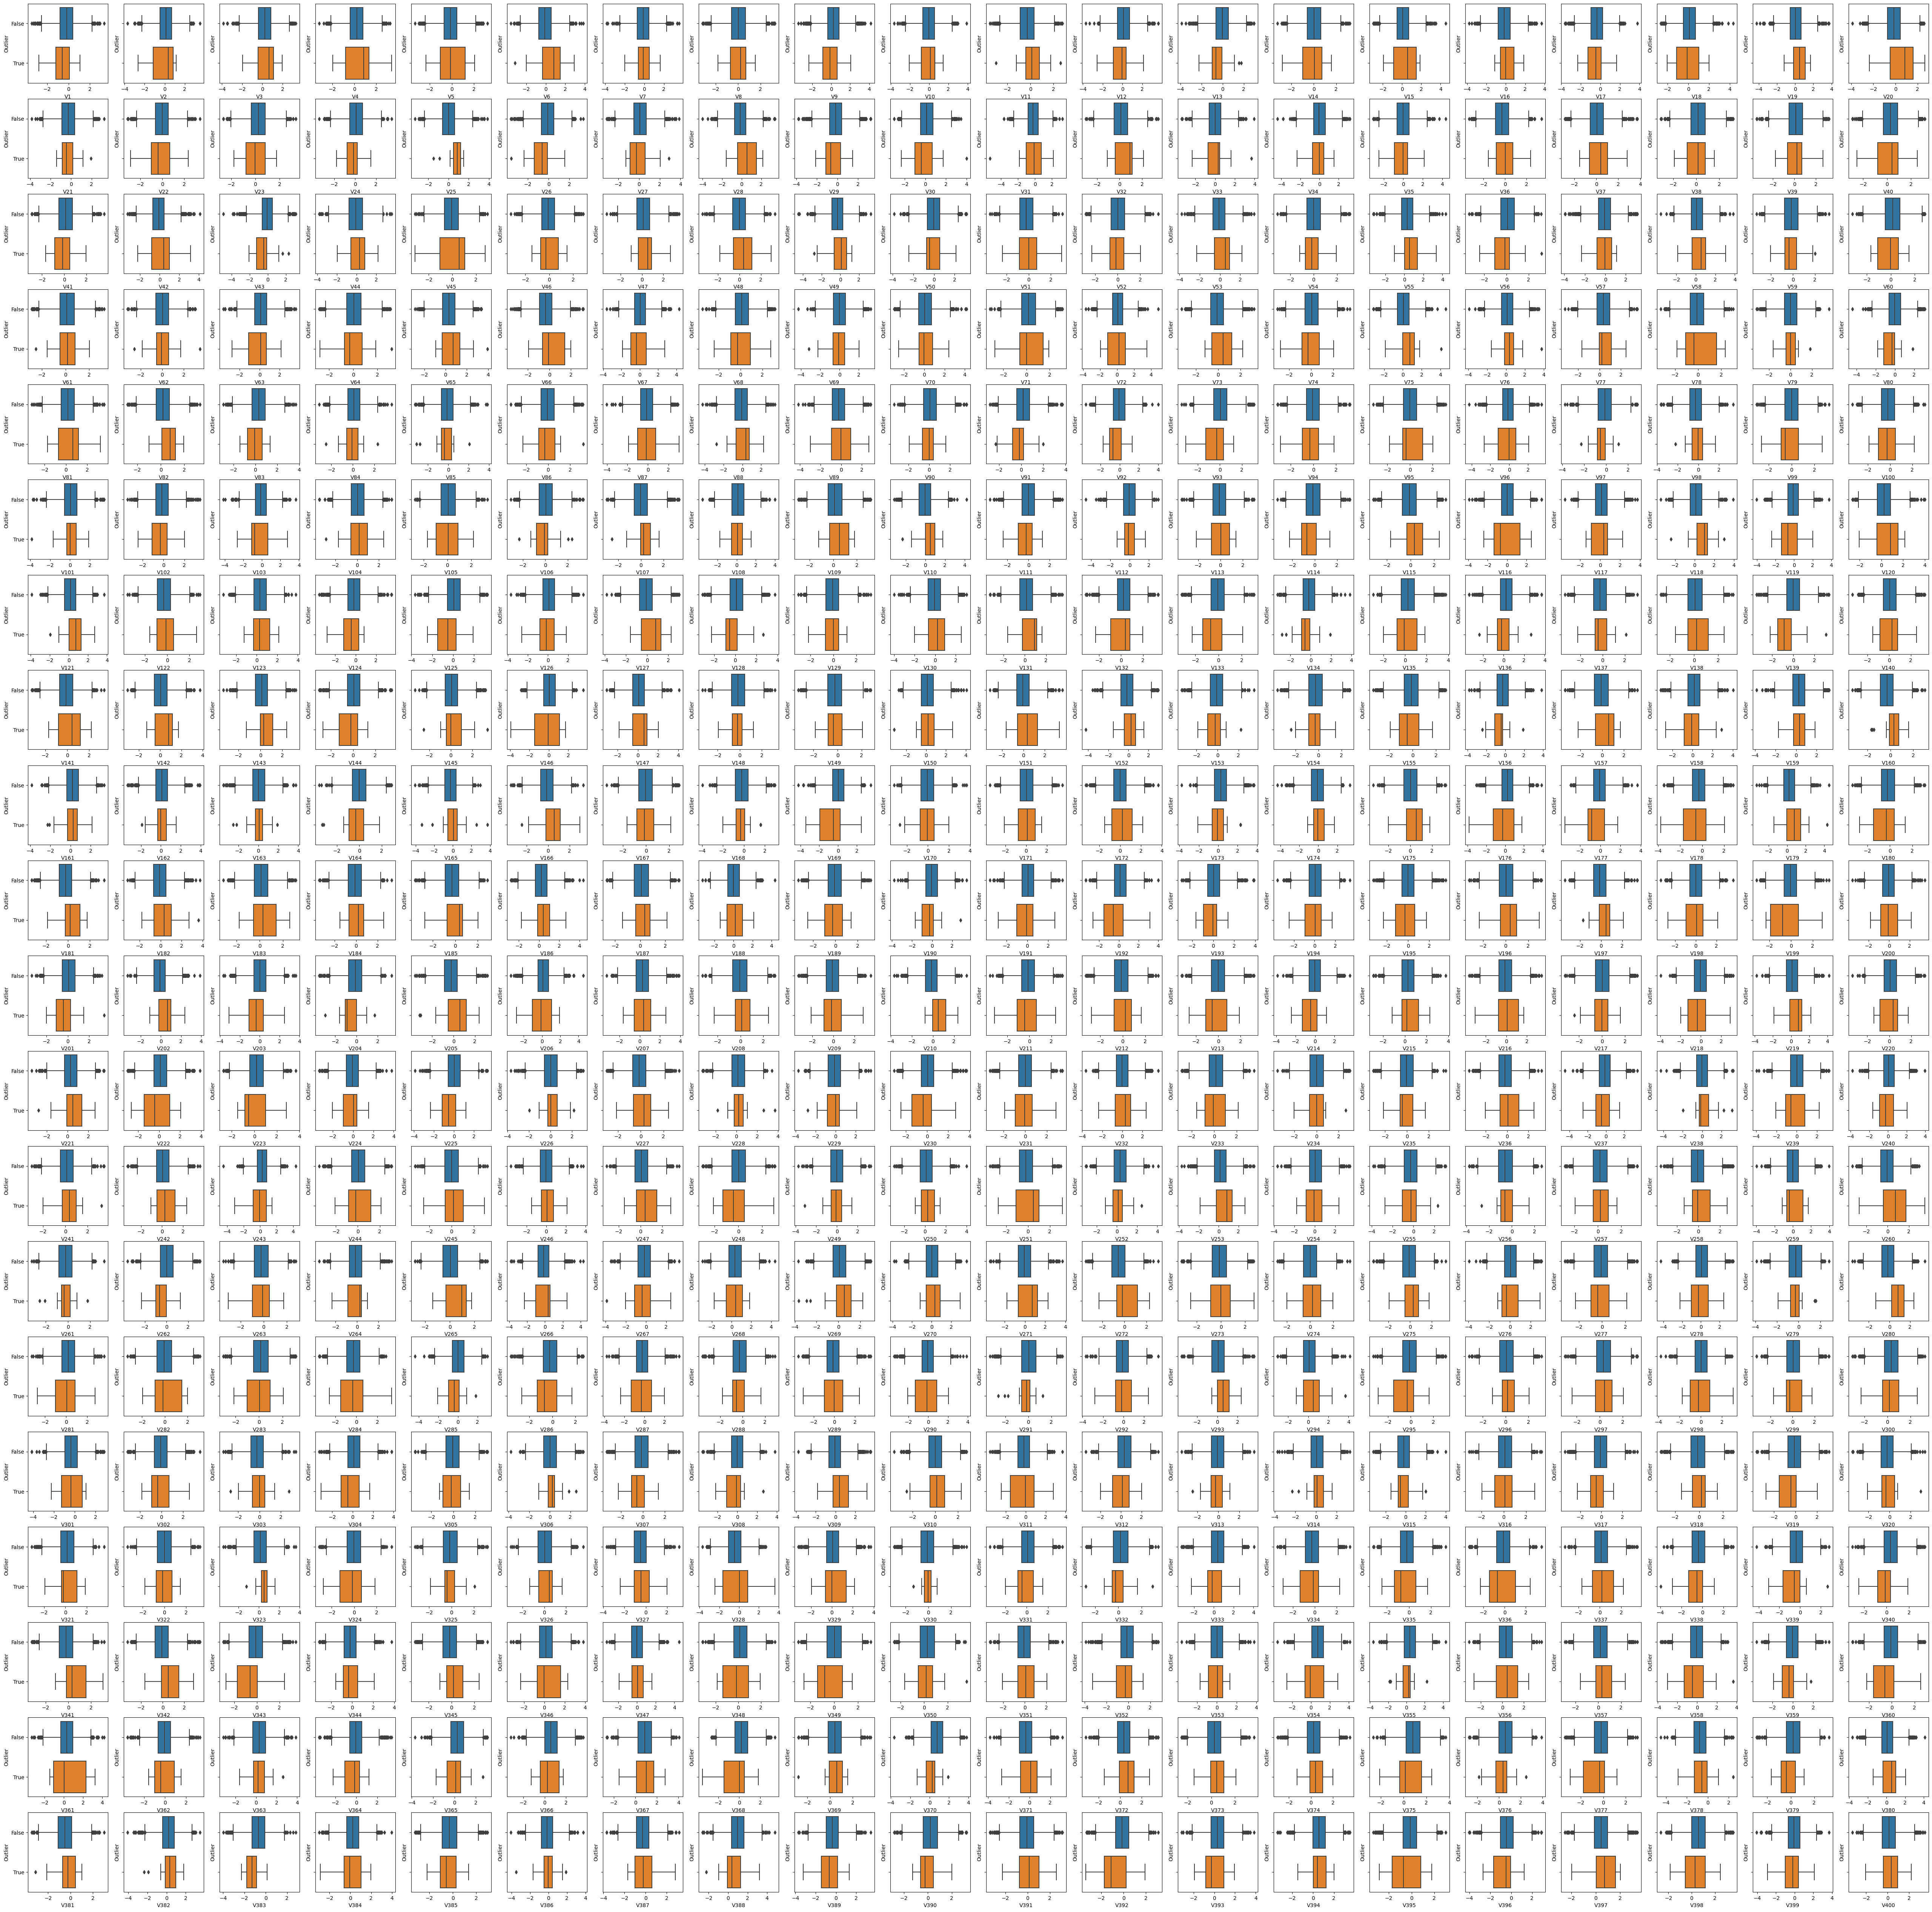

In [3]:
# Listing 6.5 Plotting the relationship between features and HBOS scores
# ----------------------------------------------------------------------

df['HBOS Score'] = pred
df['Outlier'] = (df['HBOS Score'] > df['HBOS Score'].quantile(0.995))
 
fig, ax = plt.subplots(nrows=20, ncols=20, sharey=True, figsize=(65, 65))
 
for i in range(20):
  for j in range(20):
    col_name = f"V{(i*20) + j + 1}"
    sns.boxplot(data=df, x=col_name, orient='h', y='Outlier', ax=ax[i][j])
plt.show()


C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

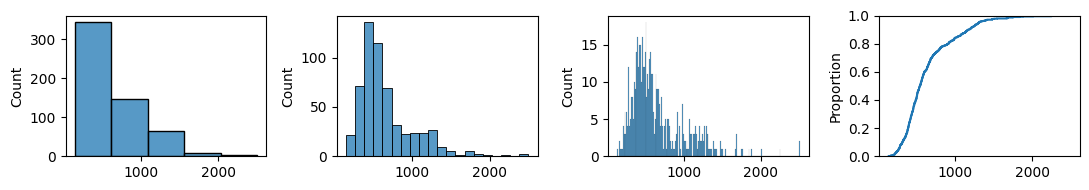

In [4]:
# Listing 6.6 Example using an ecdf plot from Seaborn
# ---------------------------------------------------

from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import seaborn as sns
 
data = load_breast_cancer()['data']
col = 3
 
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(11, 2))
sns.histplot(data[:, col], ax=ax[0], bins=5)
sns.histplot(data[:, col], ax=ax[1], bins=20)
sns.histplot(data[:, col], ax=ax[2], bins=200)
sns.ecdfplot(data[:, col], ax=ax[3])
plt.tight_layout()
plt.show()

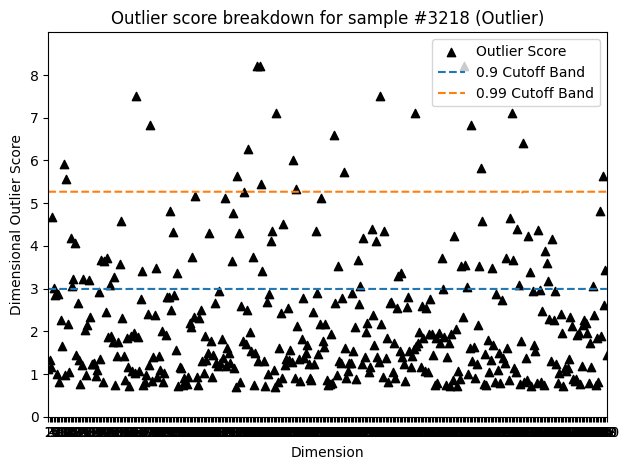

In [5]:
# Listing 6.7 ECOD with the speech dataset 
# ----------------------------------------

import pandas as pd
import numpy as np
from pyod.models.ecod import ECOD
from sklearn.datasets import fetch_openml
 
data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
 
det = ECOD()
det.fit(df)
pred = det.decision_scores_
 
det.explain_outlier(np.argmax(pred))


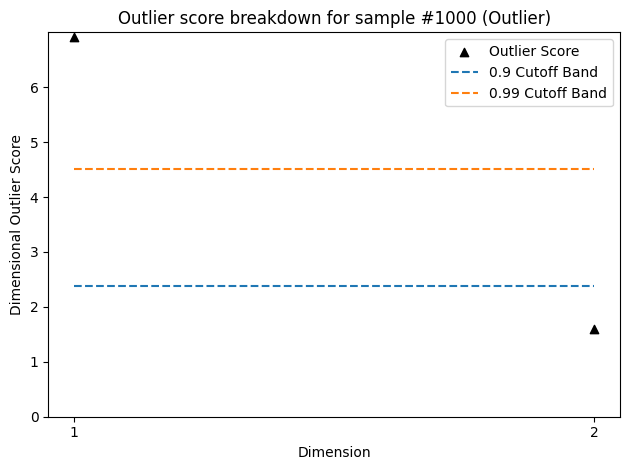

In [6]:
# Listing 6.8 Example of COPOD with synthetic data
# ------------------------------------------------

import pandas as pd
import numpy as np
from pyod.models.copod import COPOD
 
np.random.seed(42)
a_data = np.random.normal(loc=10, scale=1.0, size=1000) 
b_data = np.random.normal(loc=10, scale=1.0, size=1000)
df = pd.DataFrame({"A": a_data, "B": b_data})
df.loc[999, 'A'] = 15
 
clf = COPOD()  
clf.fit(df)
clf.explain_outlier(999)

In [7]:
# Listing 6.9 Example using scikit-learn’s PCA class to transform 2D data
# -----------------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
 
x_data = np.random.random(100)
y_data = np.random.random(100) / 10.0
 
data = pd.DataFrame({'A': x_data, 'B': x_data + y_data})
data= pd.concat([data, 
   pd.DataFrame([[1.8, 1.8], [0.5, 0.1]], columns=['A', 'B'])])
 
pca = PCA(n_components=2)
pca.fit(data)
print(pca.explained_variance_ratio_)
 
new_data = pd.DataFrame(pca.transform(data), columns=['0', '1'])


[0.99331551 0.00668449]


In [9]:
# Listing 6.10 Using ECOD to clean data before using PCA for outlier detection
# ----------------------------------------------------------------------------

import pandas as pd
from pyod.models.pca import PCA
from pyod.models.ecod import ECOD
from sklearn.datasets import fetch_openml

# Collect the data
data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
scores_df = df.copy()

# Create an ECOD detector to clean the data
clf = ECOD(contamination=0.01)
clf.fit(df)
scores_df['ECOD Scores'] = clf.predict(df)

# Create a clean version of the data, removing the top outliers found by ECOD
clean_df = df[scores_df['ECOD Scores'] == 0]

# Fit a PCA detector to the clean data
clf = PCA(contamination=0.02)
clf.fit(clean_df)

# Predict on the full data
pred = clf.predict(df)

In [10]:
# Listing 6.11 Testing SOD with 35 features
# -----------------------------------------

import pandas as pd
import numpy as np
from pyod.models.sod import SOD
 
np.random.seed(0)
d = np.random.randn(100, 35)
d = pd.DataFrame(d)
d[9] = d[9] + d[8]
d.loc[99, 8] = 3.5
d.loc[99, 9] = -3.8
 
clf = SOD(ref_set=3, contamination=0.01)
d['SOD Scores'] = clf.fit (d)
d['SOD Scores'] = clf.labels_

In [ ]:
# pip install pythresh 

In [13]:
# Listing 6.13 Example using thresholds with a single detector
# ------------------------------------------------------------

import pandas as pd
from pyod.models.knn import KNN
# FILTER (based on distinctions in the frequencies of anomalies versus inliers),
from pyod.models.thresholds import FILTER
from sklearn.datasets import fetch_openml
 
data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
 
clf = KNN()
clf.fit(df)
 
decision_scores = clf.decision_scores_  
 
thres = FILTER()
labels = thres.eval(decision_scores)
print(labels.tolist().count(0), labels.tolist().count(1))

2941 745


In [14]:
# Listing 6.14 Example using the COMB method
# ------------------------------------------

import pandas as pd
from pyod.models.knn import KNN
# COMB combines the results of multiple thresholders.
from pythresh.thresholds.comb import COMB
from sklearn.datasets import fetch_openml
 
data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
 
clf = KNN()
clf.fit(df)
 
decision_scores = clf.decision_scores_  
 
thres = COMB()
labels = thres.eval(decision_scores)
print(labels.tolist().count(0), labels.tolist().count(1))

3158 528


In [16]:
# Listing 6.15 Example using thresholds with multiple detectors
# -------------------------------------------------------------

import pandas as pd
import numpy as np
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.pca import PCA
from pyod.models.thresholds import OCSVM
from sklearn.datasets import fetch_openml
 
np.random.seed(0)

# Collect the data
data = fetch_openml("speech", version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)

# Create three detectors
knn_det = KNN()
iforest_det = IForest()
pca_det = PCA()

# Collect the scores from all three detectors on all rows
scores = []
scores.append(knn_det.fit(df).decision_function(df))
scores.append(iforest_det.fit(df).decision_function(df))
scores.append(pca_det.fit(df).decision_function(df))

# Transpose the set of scores
scores = np.vstack(scores).T

# Create a OCSVM thresholder to create binary labels based on all three numeric scores
thres = OCSVM()
labels = thres.eval(scores)
print(labels.tolist().count(0), labels.tolist().count(1))

C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


3674 12


In [9]:
# Listing 7.1 Creating first synthetic test set, a single Gaussian cluster
# ------------------------------------------------------------------------

import numpy as np
import pandas as pd
 
def create_simple_testdata():
    np.random.seed(0)
    a_data = np.random.normal(size=100)
    b_data = np.random.normal(size=100)
    df = pd.DataFrame({"A": a_data, "B": b_data})
    return df

x = create_simple_testdata()
x.head()


,A,B
0,1.764052,1.883151
1,0.400157,-1.347759
2,0.978738,-1.270485
3,2.240893,0.969397
4,1.867558,-1.173123


           A         B
0  28.528105  2.045444
1  25.800314  5.900177
2  26.957476  3.697286
3  29.481786  3.793562
4  28.735116  4.821197


<Axes: xlabel='A', ylabel='B'>

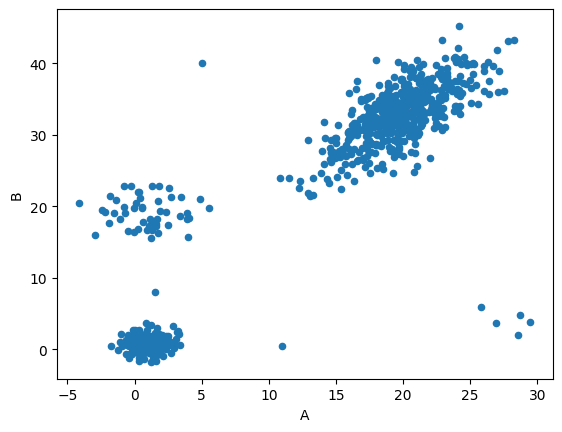

In [48]:
# Listing 7.2 Creating second synthetic test set, a set of four clusters
# ----------------------------------------------------------------------

import numpy as np
import pandas as pd
 
def create_four_clusters_test_data():
    np.random.seed(0)

    # Create a very small cluster of 5 elements
    a_data = np.random.normal(loc=25.0, scale=2.0, size=5)
    b_data = np.random.normal(loc=4.0, scale=2.0, size=5)
    df0 = pd.DataFrame({"A": a_data, "B": b_data})

    # Create a small, but not anomalous, cluster of 50 elements
    a_data = np.random.normal(loc=1.0, scale=2.0, size=50)
    b_data = np.random.normal(loc=19.0, scale=2.0, size=50)
    df1 = pd.DataFrame({"A": a_data, "B": b_data})

    # Create a cluster of 200
    a_data = np.random.normal(loc=1.0, scale=1.0, size=200)
    b_data = np.random.normal(loc=1.0, scale=1.0, size=200)
    df2 = pd.DataFrame({"A": a_data, "B": b_data})

    # Create a cluster of 500, with correlation
    a_data = np.random.normal(loc=20.0, scale=3.0, size=500)
    b_data = np.random.normal(loc=13.0, scale=3.0, size=500) + a_data
    df3 = pd.DataFrame({"A": a_data, "B": b_data})

    # Create a set of 3 global outliers
    outliers = [[5.0, 40],
                [1.5, 8.0],
                [11.0, 0.5]]
    df4 = pd.DataFrame(outliers, columns=['A', 'B'])
 
    df = pd.concat([df0, df1, df2, df3, df4])
    df = df.reset_index(drop=True)
    return df

# test plot dataframe
df = create_four_clusters_test_data()

print(df.head())

# plt.scatter(df.x, df.y)
df.plot.scatter(x='A', y='B')

In [1]:
# pip install pycaret

Defaulting to user installation because normal site-packages is not writeable
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached ipywidgets-8.1.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached imbalanced_learn-0.12.3-py3-none-any.whl.metadata (8.3 kB)
  Using cached category_encoders-2.6.3-py2.py3-none-any.whl.metadata (8.0 kB)
  Using cached lightgbm-4.3.0-py3-none-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.7.5-cp311-cp311-win_amd64.whl.metadata (5.8 kB)
  Using cached scikit_plot-0.3.7-py3-none-any.whl.metadata (7.1 kB)
  Using cached yellowbrick-1.5-py3-none-any.whl.metadata (7.7 kB)
  Using cached plotly_resampler-0.10.0-py3-none-any.whl.metadata (13 kB)
  Using cached sktime-0.26.0-py3-none-any.whl.metadata (29 kB)
  Using cached tbats-1.1.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached pmdarima-2.0.4-cp311-cp311-win_amd64.whl.metadata (8.0 kB)
  Using cached dash-2.17.0-py3-none-any.whl.metadata (10 kB)
  Using cached flask-3.0.3-

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.6.4 requires numpy<1.26,>=1.16.0, but you have numpy 1.26.4 which is incompatible.


In [4]:
# Listing 7.3 Example using PyCaret on test data using the KNN detector
# ---------------------------------------------------------------------

from pycaret.datasets import get_data
from pycaret.anomaly import *
 
df = create_four_clusters_test_data()
setup(data=df)
knn = create_model('knn')
knn_predictions = predict_model(model=knn, data=df)

,Description,Value
0,Session id,579
1,Original data shape,"(758, 2)"
2,Transformed data shape,"(758, 2)"
3,Numeric features,2
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


In [5]:
knn_predictions

,A,B,Anomaly,Anomaly_Score
0,28.528105,2.045444,1,4.722267
1,25.800314,5.900177,1,4.722267
2,26.957476,3.697286,1,2.526146
3,29.481786,3.793562,1,4.241588
4,28.735116,4.821197,1,3.126861
...,...,...,...,...
753,19.852028,36.029110,0,0.572776
754,20.717101,30.649408,0,0.393697
755,5.000000,40.000000,1,12.255619
756,1.500000,8.000000,1,4.982764


In [7]:
pip install PyNomaly

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for PyNomaly: filename=PyNomaly-0.3.3-py3-none-any.whl size=8489 sha256=7d2e7e5bbef4cc3429c9f99e7c89258a7a3dd0f6c0e65c9d0ea9e2519ab15c79
  Stored in directory: c:\users\gcart\appdata\local\pip\cache\wheels\64\fd\03\9f5bc4e0f39378aeaa78e91180d5a6bd5b2202bcb75898c689
Successfully built PyNomaly
Note: you may need to restart the kernel to use updated packages.


[ ===================================================================================== ] 100.00%====== ] 100.00%

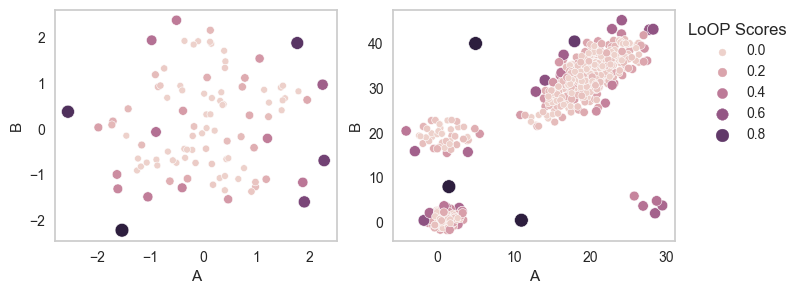

In [11]:
# Listing 7.4 Example using LoOP
# ------------------------------

from PyNomaly import loop
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_style("whitegrid", {'axes.grid' : False})

# Create a test dataset
df = create_simple_testdata()

# Create a LoOP detector
m = loop.LocalOutlierProbability(df, use_numba=True, 
                                 progress_bar=True).fit()
scores = m.local_outlier_probabilities

# Collect the outlier scores for each record
df['LoOP Scores'] = scores

# Plot the results
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
sns.scatterplot(data=df, x='A', y='B', hue='LoOP Scores', 
                size='LoOP Scores', ax=ax[0])
ax[0].legend().remove()

# Repeat the above for the 2nd test dataset
df = create_four_clusters_test_data()
m = loop.LocalOutlierProbability(df, use_numba=True,
                                 progress_bar=True).fit()
scores = m.local_outlier_probabilities
df['LoOP Scores'] = scores
 
sns.scatterplot(data=df, x='A', y='B', hue='LoOP Scores', 
                size='LoOP Scores', ax=ax[1])
sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1, 1))
plt.show()

In [6]:
# Listing 7.5 LDOF outlier detection
# ----------------------------------

import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
from sklearn.preprocessing import RobustScaler
import seaborn as sns

class LDOFOutlierDetector:
    def __init__(self):
        pass
    
    def fit_predict(self, df, k):
        # Calculate the kNN distances: the average distances to the k nearest neighbors for all records
        balltree = BallTree(df)
        dist, ind = balltree.query(df, k=k) 
        knn_distances = [x.mean() for x in dist]

        # Loop through each record in the data
        inner_distances = []
        for i in df.index:
            # Calculate the average distances from the k nearest neighbors to each other.
            local_balltree = BallTree(df.loc[ind[i]])
            local_dist, local_ind = balltree.query(df.loc[ind[i]], k=k)
            inner_distances.append(local_dist.mean())

        # Take the ratio of these
        return np.array(knn_distances) / np.array(inner_distances)
        
df = create_four_clusters_test_data()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
 
clf = LDOFOutlierDetector()
df['LDOF Score'] = clf.fit_predict(df, k=20)


# plot results - CODE FAILS, NO PLOT DISPLAYED
sns.scatterplot(data=df, x='A', y='B', hue='LDOF Score', 
                size='LDOF Score', ax=ax[1])
sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1, 1))
plt.show()

In [18]:
# Listing 7.7 ODIN outlier detection
# ----------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree
from collections import Counter
 
class ODINOutlierDetector:
    def __init__(self):
        pass
    
    def fit_predict(self, df_in, k):
        df = df_in.copy()
        num_rows = len(df)
        b = BallTree(df)
        dist, ind = b.query(df, k=k)
 
        df['ODIN Score'] = [0] * num_rows
        for current_k in range(1, k):
            current_ind = ind[:, current_k]
            c = Counter(current_ind)
            g = [(x, c[x]) if x in c else (x, 0) for x in range(num_rows)]
            df['ODIN Score'] += \
                (k - current_k) * np.array([x[1] for x in g])
 
        min_score = df['ODIN Score'].min()
        max_score = df['ODIN Score'].max()
        return (max_score - df['ODIN Score']) / (max_score - min_score)        
 
np.random.seed(0)
df = create_four_clusters_test_data()
 
clf = ODINOutlierDetector()
df['ODIN Score'] = clf.fit_predict(df, k=20)

In [20]:
# Listing 7.8 Clustering and calculating the Mahalanobis distances per cluster
# ----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest
 
def cluster_based_outliers(df, sizes_weight=0.05):
    # Filter the strong outliers using an IF
    clf_if = IsolationForest()
    clf_if.fit(df)
    pred = clf_if.decision_function(df)
    trimmed_df = df.loc[np.argsort(pred)[50:]]

    # Find the best number of clusters
    best_score = np.inf
    best_n_clusters = -1
    for n_clusters in range(2, 10):
        gmm = GaussianMixture(n_components=n_clusters)
        gmm.fit(trimmed_df)
        score = gmm.bic(trimmed_df)
        if score < best_score:
            best_score = score
            best_n_clusters = n_clusters

    # Perform the clustering
    gmm = GaussianMixture(n_components=best_n_clusters)
    gmm.fit(trimmed_df)
    X = df.copy()
    X['Cluster ID'] = gmm.predict(df)

    # Find the sizes of the clusters
    vc = pd.Series(X['Cluster ID']).value_counts()
    cluster_counts_dict = {x: y for x, y in zip(vc.index, vc.values)}
    size_scores = [cluster_counts_dict[x] for x in X['Cluster ID']]
    scaler = MinMaxScaler()
    size_scores = scaler.fit_transform(
        np.array(size_scores).reshape(-1, 1))
    size_scores = np.array(size_scores).reshape(1, -1)[0]
    size_scores = np.array([1.0 - x for x in size_scores])

    # Find the actual vs average Mahalanobis distances
    dfs_arr = []
    for cluster_idx in range(best_n_clusters):
        cluster_df = X[X['Cluster ID'] == cluster_idx].copy()
        cov = MinCovDet(random_state=0).fit(cluster_df[df.columns])
        cluster_df['Mahalanobis Dist'] = \
            cov.mahalanobis(cluster_df[df.columns])
        cluster_df['Mahalanobis Dist'] = \
            (cluster_df['Mahalanobis Dist'] /
             cluster_df['Mahalanobis Dist'].mean())
        dfs_arr.append(cluster_df)
    maha_scores = pd.concat(dfs_arr).sort_index()['Mahalanobis Dist']
    scaler = MinMaxScaler()
    maha_scores = scaler.fit_transform(
        np.array(maha_scores).reshape(-1, 1))
    maha_scores = np.array(maha_scores).reshape(1, -1)[0]
    return (sizes_weight * size_scores) + maha_scores
 
df = create_four_clusters_test_data()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
df['Cluster-Based Scores'] = cluster_based_outliers(df)

In [22]:
# Listing 7.9 Clustering using KDE and multiple clusterings
# ---------------------------------------------------------

from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans
 
def cluster_based_outliers(df, min_n_clusters=1, max_n_clusters=20,
                           n_trials=10):
    scores_df = pd.DataFrame()
    scores_col_name = 0
    X = df.copy()
    # Loop through each number of clusters
    for n_clusters in range(min_n_clusters, max_n_clusters+1):
        # Loop through each trial
        for trial_idx in range(n_trials):
            seed = n_clusters * 100 + trial_idx
            np.random.seed(seed)
            kmeans = KMeans(n_clusters=n_clusters, random_state=seed, 
               # Use k-means to cluster the data with the specified number of clusters and random seed
               init='random', n_init="auto").fit(df)
            X['Cluster ID'] = kmeans.labels_
 
            dfs_arr = []
            # Loop through each cluster
            for cluster_idx in range(n_clusters):
                cluster_df = X[X['Cluster ID'] == cluster_idx].copy()
                kde = KernelDensity(
                    # Calculate the KDE for the current cluster
                    kernel='gaussian').fit(cluster_df[df.columns])
                kde_scores = (-1) * \
                   kde.score_samples(cluster_df[df.columns])
                # Find the KDE for each point relative to the average KDE for this cluster
                cluster_df['KDE Score'] = kde_scores / kde_scores.mean()
                dfs_arr.append(cluster_df)
 
            scores_col_name += 1
            scores_df = pd.concat([scores_df, 
              pd.concat(dfs_arr).sort_index()['KDE Score']], axis=1)
    return scores_df.mean(axis=1)
 
df = create_four_clusters_test_data()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
df['Cluster-Based Scores'] = cluster_based_outliers(df)

In [23]:
# pip install kmodes

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
# Listing 7.10 Outlier detection using the kmodes clustering algorithm
# --------------------------------------------------------------------

import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
 
class kmodesOutlierDetector:
  def __init__(self, n_clusters):
    self.n_clusters = n_clusters
 
  def fit_predict(self, df):
    km = KModes(n_clusters=self.n_clusters, init='Huang', n_init=5)
    clusters = km.fit_predict(df)
    df_copy = df.copy()
    df_copy['Cluster'] = clusters
 
    scores = [-1] * len(df)
    for cluster_idx in range(self.n_clusters):
      cluster_df = df_copy[df_copy['Cluster'] == cluster_idx]
      center = km.cluster_centroids_[cluster_idx]
      for i in cluster_df.index:
        row = cluster_df.loc[i]
        num_diff = 0
        for j in range(len(center)):
          if row[j] != center[j]:
            num_diff += 1
        scores[i] = num_diff
    return scores
 
np.random.seed(0)
data = np.random.choice(['A', 'B', 'C'], (100, 2))
df = pd.DataFrame(data, columns=['F1', 'F2'])
df['F3'] = df['F2']
df['F4'] = df['F1'] + df['F2']
df.loc[99] = ['A', 'A', 'B', 'CC']
 
clf = kmodesOutlierDetector(n_clusters=9)
scores = clf.fit_predict(df)
df['KModes Scores'] = scores
df.tail() 

,F1,F2,F3,F4,KModes Scores
95,A,C,C,AC,0
96,C,B,B,CB,0
97,B,B,B,BB,0
98,C,A,A,CA,0
99,A,A,B,CC,2


In [26]:
# Listing 7.11 Example of outlier detection using entropy
# =======================================================

class EntropyOutlierDetector:
  def __init__(self, num_outliers, num_bins=7):
    self.num_outliers = int(num_outliers)
    self.num_bins = num_bins
 
  def calculate_entropy(self, values):
      vc = values.value_counts(normalize=True)
      entropy = 0.0
      for v in vc.values:
          if v > 0:
              entropy += ((v) * np.log2(v))
      entropy = (-1) * entropy
      return entropy
 
  def fit_predict(self, df):
    df = df.copy()
    df['A binned'] = pd.cut(df[df.columns[0]], bins=self.num_bins)
    df['B binned'] = pd.cut(df[df.columns[1]], bins=self.num_bins)
 
    temp_df = df.copy()
    scores = [0]*len(df)
    for iteration_num in range(self.num_outliers):
        lowest_entropy = np.inf
        lowest_entropy_row = -1
        for i in temp_df.index:
            a_entropy = self.calculate_entropy(temp_df['A binned'].drop(i))
            b_entropy = self.calculate_entropy(temp_df['B binned'].drop(i))
            total_entropy = a_entropy + b_entropy
            if total_entropy < lowest_entropy:
                lowest_entropy = total_entropy
                lowest_entropy_row = i
 
        scores[lowest_entropy_row] = (self.num_outliers - iteration_num)
        temp_df = temp_df.drop(index=lowest_entropy_row)
    return scores
 
df = create_four_clusters_test_data()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
df['Entropy Scores'] = EntropyOutlierDetector(num_outliers=10, num_bins=10).fit_predict(df)


In [27]:
# pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [28]:
# Listing 7.12 Creating Frequent Item Sets (FISs)
# -----------------------------------------------

from mlxtend.frequent_patterns import apriori
import pandas as pd
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as seaborn
 
data = fetch_openml('SpeedDating', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)
data_df = data_df[['d_pref_o_attractive', 'd_pref_o_sincere',  
                   'd_pref_o_intelligence', 'd_pref_o_funny', 
                   'd_pref_o_ambitious', 'd_pref_o_shared_interests']]
data_df = pd.get_dummies(data_df)
for col_name in data_df.columns:
    data_df[col_name] = data_df[col_name].map({0: False, 1: True})
frequent_itemsets = apriori(data_df, min_support=0.3, use_colnames=True)

ValueError: The allowed values for a DataFrame are True, False, 0, 1. Found value nan

In [29]:
data_df

,d_pref_o_attractive_[0-15],d_pref_o_attractive_[16-20],d_pref_o_attractive_[21-100],d_pref_o_sincere_[0-15],d_pref_o_sincere_[16-20],d_pref_o_sincere_[21-100],d_pref_o_intelligence_[0-15],d_pref_o_intelligence_[16-20],d_pref_o_intelligence_[21-100],d_pref_o_funny_[0-15],d_pref_o_funny_[16-20],d_pref_o_funny_[21-100],d_pref_o_ambitious_[0-15],d_pref_o_ambitious_[16-20],d_pref_o_ambitious_[21-100],d_pref_o_shared_interests_[0-15],d_pref_o_shared_interests_[16-20],d_pref_o_shared_interests_[21-100]
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Listing 7.15 Example code for ConvexHull outlier detector
# ---------------------------------------------------------

from scipy.spatial import ConvexHull
import numpy as np
import pandas as pd
 
class ConvexHullOutlierDetector:
  def __init__(self, num_iterations):
    self.num_iterations = num_iterations
 
  def fit_predict(self, df):
    scores = [0] * len(df)
    remaining_df = df.copy()
    remaining_df['Row Idx'] = remaining_df.index
 
    for iteration_idx in range(self.num_iterations):
        hull = ConvexHull(remaining_df[[df.columns[0], df.columns[1]]])
 
        simplex_idxs = [y for x in hull.simplices for y in x]
        simplex_idxs = list(set(simplex_idxs))
        for idx in simplex_idxs:
            orig_row_idx = remaining_df.loc[idx, 'Row Idx']
            scores[orig_row_idx] = (self.num_iterations - iteration_idx)
            remaining_df = remaining_df.drop(index=idx)
        remaining_df = remaining_df.reset_index(drop=True)
 
    return scores
 
df = create_four_clusters_test_data()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
df['ConvexHull Scores'] = ConvexHullOutlierDetector(num_iterations=2).fit_predict(df)

In [34]:
# Listing 7.16 Distance Metric Learning outlier detection
# -------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from collections import Counter
 
class DMLOutlierDetection:
    def __init__(self):
        pass
 
    def fit_predict(self, df):
        real_df = df.copy()
        real_df['Real'] = True
        # Generate synthetic data that is similar to the real data
        synth_df = pd.DataFrame()
        for col_name in df.columns:
            mean = df[col_name].mean()
            stddev = df[col_name].std()
            synth_df[col_name] = np.random.normal(loc=mean, 
               scale=stddev, size=len(df))
        synth_df['Real'] = False
 
        train_df = pd.concat([real_df, synth_df])
 
        clf = RandomForestClassifier(max_depth=5)
        clf.fit(train_df.drop(columns=['Real']), train_df['Real'])

        # Get the leaf node each record ends in
        r = clf.apply(df)

        # Initialize the score for all records to 0
        scores = [0]*len(df)

        # Loop through each tree in the Random Forest
        for tree_idx in range(len(r[0])):
            # Get the count of each leaf node
            c = Counter(r[:, tree_idx])
            # Loop through each record and update its score based on the frequency of the node it ends in
            for record_idx in range(len(df)):
                node_idx = r[record_idx, tree_idx]
                node_count = c[node_idx]
                scores[record_idx] += len(df) - node_count
 
        return scores
 
df = create_four_clusters_test_data()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
clf = DMLOutlierDetection()
df['Scores'] = clf.fit_predict(df)


In [36]:
# Listing 7.17 NearestSample outlier detection
# --------------------------------------------

import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.neighbors import BallTree
 
class NearestSampleOutlierDetector:
    def __init__(self, n_iterations=10, n_samples=100, 
                 show_progress=False):
        self.n_iterations = n_iterations
        self.n_samples = n_samples
        self.show_progress = show_progress
        self.training_df = None
        self.orig_cols = None
        self.tree = None
 
    def fit(self, df):
      self.training_df = df.copy()
      self.orig_cols = df.columns
 
    def decision_function(self, df_in):
      df = pd.DataFrame(df_in).copy()
      # Create a BallTree representing the full dataset
      self.balltree = BallTree(df)

      # Loop through a specified number of iterations (optionally showing progress at each step)
      if self.show_progress:
        for iteration_idx in tqdm(range(self.n_iterations)):
            scores = self.execute_iteration(df)
            self.df[f'Scores_{iteration_idx}'] = scores
      else:
        for iteration_idx in range(self.n_iterations):
            scores = self.execute_iteration(df)
            df[f'Scores_{iteration_idx}'] = scores
 
      score_cols = [f'Scores_{x}' for x in range(iteration_idx)]
      df['Score'] = df[score_cols].sum(axis=1)
 
      return df['Score'].values

    # Execute this function each iteration
    def execute_iteration(self, prediction_df):
        sample_idxs = np.random.choice(range(len(self.training_df)), 
                                       # Select a random sample of records
                                       self.n_samples)
 
        distances_arr = []
        # Loop through each sample record
        for sample_idx in sample_idxs:
            row = self.training_df.iloc[sample_idx: sample_idx+1]
            dist, ind = self.balltree.query(row[self.orig_cols],
                          # Get the distance of all points to this sample
                          k=len(prediction_df))
            dist = dist[0]
            ind = ind[0]
            ordered_idxs = np.argsort(ind)
            dist = pd.Series(dist)
            distances_arr.append(dist.loc[ordered_idxs].values)

        # Set distances_arr to the minimum distance to a sample point for each record
        distances_df = pd.DataFrame(distances_arr).T
        return np.array(distances_df.min(axis=1))
 
df = create_four_clusters_test_data()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
df['NearestSample Scores'] = \
NearestSampleOutlierDetector().fit(df).decision_function(df)

AttributeError: 'NoneType' object has no attribute 'decision_function'

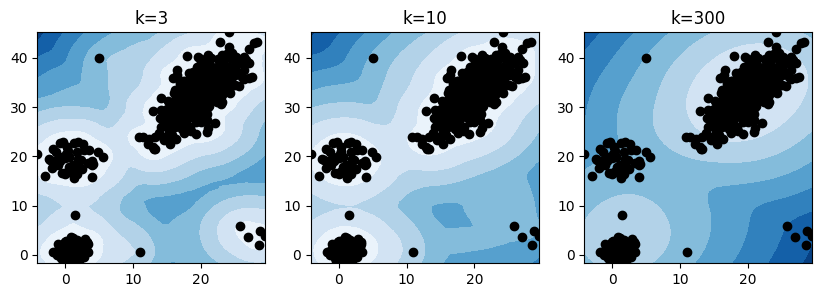

In [4]:
# Listing 8.4 Code to render a contour plot of a detector
# -------------------------------------------------------

from pyod.models.knn import KNN 
import matplotlib.pyplot as plt
 
def plot_scatterplot(k, ax): 
  clf = KNN(n_neighbors=k, method='mean')
  clf.fit(df)
 
  Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
 
  ax.contourf(xx, yy, Z, cmap='Blues')
  ax.scatter(data=df, x="A", y='B', color='black')
  ax.set_title(f"k={k}")

# Create test data
df = create_four_clusters_test_data()
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

# Create a mesh of points within the range of the data
xx, yy = np.meshgrid(
    np.linspace(df['A'].min(), df['A'].max(), 50), 
    np.linspace(df['B'].min(), df['B'].max(), 50))

# Render contour and scatter plots of different values of k
plot_scatterplot(3, ax[0])
plot_scatterplot(10, ax[1])
plot_scatterplot(300, ax[2])
 
plt.axis('tight')
plt.legend().remove()
plt.show()

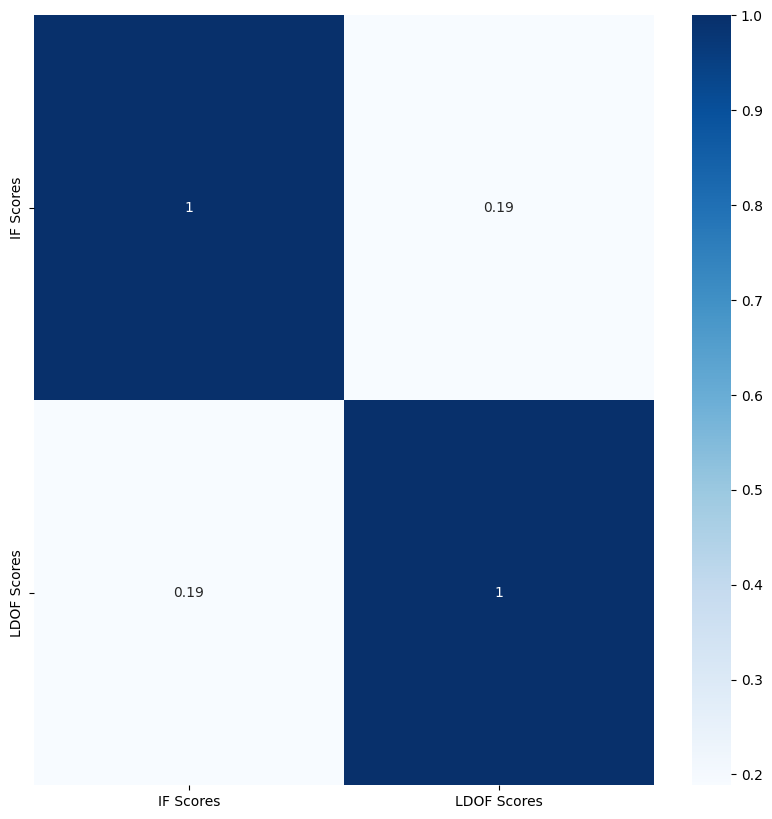

In [8]:
# Listing 8.5 Testing the output of detectors on the abalone dataset for correlations
# -----------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import BallTree

from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM
from pyod.models.gmm import GMM
from pyod.models.kde import KDE
from pyod.models.knn import KNN
from pyod.models.hbos import HBOS
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD

# Collect the data
data = fetch_openml('abalone', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df = pd.get_dummies(df)
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
 
def score_records():
  scores_df = df.copy()

  # Create a detector and collect the scores it produces
  clf = IForest()
  clf.fit(df)
  scores_df['IF Scores'] = clf.decision_scores_
 
  # (similar code for LOF, OCSVM, GMM, KDE, HBOS, ECOD, and COPOD 
  #  as for IF)
 
  clf = LDOFOutlierDetector()
  scores_df['LDOF Scores'] = clf.fit_predict(df, k=5)
 
  return scores_df
 
scores_df = score_records()
 
fig, ax = plt.subplots(figsize=(10, 10))

# Find the set of columns with the scores
scores_cols = [x for x in scores_df.columns if "Scores" in x]

# Plot a heatmap of the correlations
m = sns.color_palette("Blues", as_cmap=True)
sns.heatmap((scores_df[scores_cols].corr(method='spearman')), 
             cmap=m, annot=True)
plt.show()

C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


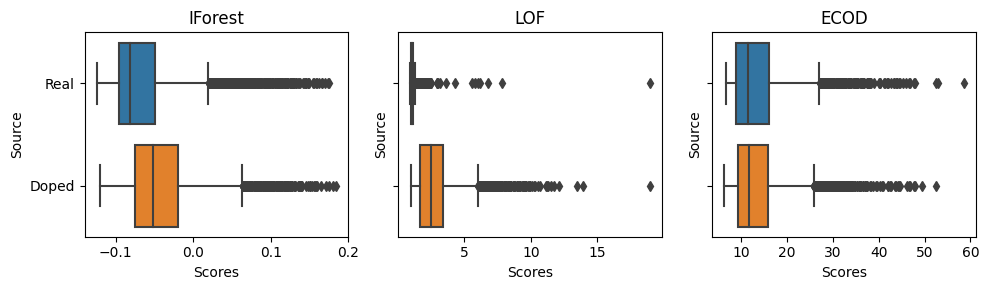

In [11]:
# Listing 8.8 Evaluation of detectors using a doping process
# ----------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD
 
data = fetch_openml('abalone', version=1)
df = pd.DataFrame(data.data, columns=data.feature_names)
df = pd.get_dummies(df)
df_orig = df.copy()
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
 
clf = IForest()
clf.fit(df)
if_scores = clf.decision_scores_
top_if_scores = np.argsort(if_scores)[::-1][:10]
clean_df = df.loc[[x for x in df.index if x not in top_if_scores]].copy()
 
doped_df = df.copy()
for i in doped_df.index:
  col_name = np.random.choice(df.columns)
  med_val = clean_df[col_name].median()
  if doped_df.loc[i, col_name] > med_val:
    doped_df.loc[i, col_name] = clean_df[col_name].quantile(np.random.random()/2)
  else:
    doped_df.loc[i, col_name] = clean_df[col_name].quantile(0.5 + np.random.random()/2)
 
def test_detector(clf, title, df, clean_df, doped_df, ax):
  clf.fit(clean_df)
  df = df.copy()
  doped_df = doped_df.copy()
  df['Scores'] = clf.decision_function(df)
  df['Source'] = 'Real'
  doped_df['Scores'] = clf.decision_function(doped_df)
  doped_df['Source'] = 'Doped'
  test_df = pd.concat([df, doped_df])
  sns.boxplot(data=test_df, orient='h', x='Scores', y='Source', ax=ax)
  ax.set_title(title)
 
fig, ax = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(10, 3))
test_detector(IForest(), "IForest", df, clean_df, doped_df, ax[0])
test_detector(LOF(), "LOF", df, clean_df, doped_df, ax[1])
test_detector(ECOD(), "ECOD", df, clean_df, doped_df, ax[2])
plt.tight_layout()
plt.show()

In [12]:
# Listing 8.9 Evaluating detectors using AUROC
# --------------------------------------------

from sklearn.metrics import roc_auc_score
 
test_df = pd.concat([df, doped_df])
y_true = [0]*len(df) + [1]*len(doped_df)
 
clf = IForest()
clf.fit(clean_df)
y_pred = clf.decision_function(test_df)
if_auroc = roc_auc_score(y_true, y_pred)
 
clf = LOF()
clf.fit(clean_df)
y_pred = clf.decision_function(test_df)
lof_auroc = roc_auc_score(y_true, y_pred)

C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


In [13]:
# Listing 8.10 Testing adjusting the training set size
# ----------------------------------------------------


def test_training_size(n_rows):
  clf = LOF()
  clf.fit(clean_df.sample(n=n_rows))
  y_pred = clf.decision_function(test_df)
  lof_auroc = roc_auc_score(y_true, y_pred)
  return lof_auroc

In [ ]:
# Listing 8.11 Sample of code to time fit and predict times
# ---------------------------------------------------------

from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from pyod.models.pca import PCA

import time
def time_detector(clf):
  start_time = time.process_time()
  clf.fit(test_df)
  iteration_fit_results_arr.append(time.process_time() - start_time)
 
  start_time = time.process_time()
  clf.decision_function(test_df)
  iteration_predict_results_arr.append(time.process_time() - start_time)
 
data = fetch_openml('abalone', version=1)
df = pd.DataFrame(data.data, columns=data.feature_names)
df = pd.get_dummies(df)
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
 
fit_results_arr = []
predict_results_arr = []
 
for multiplier in [1, 5, 10, 15, 20, 25]:
  test_df = pd.concat([df]*multiplier)
  iteration_fit_results_arr = [len(test_df)]
  iteration_predict_results_arr = [len(test_df)]
 
  time_detector(clf = IForest())
  time_detector(clf = LOF())
  time_detector(clf = OCSVM())
  time_detector(clf = GMM())
  time_detector(clf = KDE())
  time_detector(clf = KNN())
  time_detector(clf = HBOS())
  time_detector(clf = ECOD())
  time_detector(clf = COPOD())
  time_detector(clf = ABOD())
  time_detector(clf = CBLOF())
  time_detector(clf = PCA())
 
  fit_results_arr.append(iteration_fit_results_arr)
  predict_results_arr.append(iteration_predict_results_arr)
 
col_names = ['Number Rows', 'IF', 'LOF', 'OCSVM', 'GMM', 'KDE', 'KNN', 'HBOS', 'ECOD', 'COPOD', 'ABOD', 'CBLOF', 'PCA']
fit_results_df = pd.DataFrame(fit_results_arr, columns=col_names)
display(fit_results_df)
 
predict_results_df = pd.DataFrame(predict_results_arr, columns=col_names)
display(predict_results_df)

## RUN MORE THAN 2 HOURS, ABORTED, RUN OVERNIGHT

In [2]:
# Listing 9.1 Filling None and NaN values
# ---------------------------------------

import pandas as pd
import numpy as np
 
df = pd.DataFrame({"A": [1, 2, np.NaN, 4, 5, None], 
                   "B": ['A', 'B', None, "B", "B", "F"]})
df_filled = df.copy()

# before
print(df_filled)

df_filled['A Null'] = df['A'].isna()
df_filled['B Null'] = df['B'].isna()
df_filled['Num Null'] = df.isna().sum(axis=1)
df_filled['A'] = df['A'].fillna(df['A'].median())
df_filled['B'] = df['B'].fillna(df['B'].mode()[0])

# after
print(df_filled)

     A     B
0  1.0     A
1  2.0     B
2  NaN  None
3  4.0     B
4  5.0     B
5  NaN     F
     A  B  A Null  B Null  Num Null
0  1.0  A   False   False         0
1  2.0  B   False   False         0
2  3.0  B    True    True         2
3  4.0  B   False   False         0
4  5.0  B   False   False         0
5  3.0  F    True   False         1


In [3]:
# Listing 9.2 Converting data to binary indicator of null values
# --------------------------------------------------------------

import pandas as pd
import numpy as np
 
df = pd.DataFrame({"A": [1, 2, np.NaN, 4, 5, None], 
                   "B": ['A', 'B', None, np.NaN, "E", "F"]})
# before
print(df)

# after
df_filled = df.isna()
print(df_filled)

     A     B
0  1.0     A
1  2.0     B
2  NaN  None
3  4.0   NaN
4  5.0     E
5  NaN     F
       A      B
0  False  False
1  False  False
2   True   True
3  False   True
4  False  False
5   True  False


In [4]:
# Listing 9.3 Extracting the number of characters and digits from phone numbers
# -----------------------------------------------------------------------------

def num_digits(x):
    return len([c for c in x if c.isdigit()])
 
df = pd.DataFrame({'Phone': ['123-456-9890', '555-555-5555', '555-555']})

# before
print(df)

df['Num Characters'] = df['Phone'].str.len()
df['Num Digits'] = df['Phone'].apply(num_digits)

# after
print(df)


          Phone
0  123-456-9890
1  555-555-5555
2       555-555
          Phone  Num Characters  Num Digits
0  123-456-9890              12          10
1  555-555-5555              12          10
2       555-555               7           6


In [5]:
# check for area code

def area_code(x):
    digits_only = ''.join([c for c in x if c.isdigit()])
    if len(digits_only) == 10:
        return digits_only[:3]
    if len(digits_only) == 11:
        return digits_only[1:4]
    return ''
 

In [6]:
# check for placeholders (ex: 555-555-5555)

def num_unique_digits(x):
    return len(set([c for c in x if c.isdigit()]))
 

In [ ]:
# Listing 9.4 Engineering features related to date
# ------------------------------------------------

import datetime 
import pandas as pd
import numpy as np
 
df['DOW 1'] = df['Date of Expense'].dt.dayofweek 
df['DOM 1'] = df['Date of Expense'].dt.day
df['Beg. of Month'] = df['DOM 1'].apply(lambda x: x < 15, 1, 0)
df['Gap'] = (df['Date Submitted'] - df['Date of Expense']).dt.days
df = df.drop(columns=['Date of Expense', 'Date Submitted']) 

In [9]:
# Listing 9.5 Collecting holiday dates
# ------------------------------------

from pandas.tseries.holiday import USFederalHolidayCalendar
 
cal = USFederalHolidayCalendar()
holidays = cal.holidays(
    start='2023-01-01', end='2023-12-31').to_pydatetime()

print(holidays)

[datetime.datetime(2023, 1, 2, 0, 0) datetime.datetime(2023, 1, 16, 0, 0)
 datetime.datetime(2023, 2, 20, 0, 0) datetime.datetime(2023, 5, 29, 0, 0)
 datetime.datetime(2023, 6, 19, 0, 0) datetime.datetime(2023, 7, 4, 0, 0)
 datetime.datetime(2023, 9, 4, 0, 0) datetime.datetime(2023, 10, 9, 0, 0)
 datetime.datetime(2023, 11, 10, 0, 0)
 datetime.datetime(2023, 11, 23, 0, 0)
 datetime.datetime(2023, 12, 25, 0, 0)]


In [ ]:
pip install skrub

In [17]:
# Listing 9.6 Using skrub for deduplication
# -----------------------------------------

from skrub.datasets import make_deduplication_data
from skrub import deduplicate
 
duplicated_names = make_deduplication_data(
    examples=["online course", "seminar", "conference", "in-person class", 
              "lecture series"],  
    entries_per_example=[500, 500, 500, 500, 500],  
    prob_mistake_per_letter=0.1,  
    random_state=42,  
)

print(duplicated_names)

deduplicated_data = deduplicate(duplicated_names)

#print("\n\n")
print(deduplicated_data)

['onlinevcouqse', 'online course', 'onlineacourue', 'onltne course', 'onlimepcourse', 'onlmne noursc', 'onlinf course', 'online rosrse', 'online course', 'online couroe', 'online course', 'onyinb course', 'online cjursx', 'onrine course', 'online cmurse', 'onlineecouwse', 'xnline course', 'oaline course', 'onlvne couase', 'online coursr', 'online course', 'online couosq', 'onliku course', 'zyline coursv', 'qnline course', 'online moabse', 'oiline cocrse', 'onlanu course', 'onlinp wfuqse', 'enline course', 'online course', 'onlieefcourse', 'onlineccuurse', 'onlinw eouuee', 'online jourse', 'ojlsne course', 'onqiue cnurse', 'onlini course', 'onlnne course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online course', 'online cours

In [20]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/42.0 kB ? eta -:--:--
     --------- ------------------------------ 10.2/42.0 kB ? eta -:--:--
     ------------------ ------------------- 20.5/42.0 kB 131.3 kB/s eta 0:00:01
     ------------------ ------------------- 20.5/42.0 kB 131.3 kB/s eta 0:00:01
     -------------------------------------  41.0/42.0 kB 196.9 kB/s eta 0:00:01
     -------------------------------------- 42.0/42.0 kB 184.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 435.7 kB/s eta 0:00:04
    --------------------------------------- 0.0/1.5 MB 435.7 kB/s eta 0:00:04
    --------------------------------------- 0.0/1.5 MB 435.7 kB/s eta 0:00:04
    --------------------------------------- 0.0/1.5 MB 435.7 kB/s eta 0:00:04
    ---

In [21]:
# Listing 9.7 Identifying synonyms using NLTK’s wordnet
# -----------------------------------------------------

import nltk
from nltk.corpus import wordnet
 
nltk.download('wordnet')
 
synonyms = []
for syn in wordnet.synsets("big"):
    for w in syn.lemmas():
        synonyms.append(w.name())
synonyms = list(set(synonyms))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gcart\AppData\Roaming\nltk_data...


In [22]:
synonyms

['giving',
 'bad',
 'boastful',
 'adult',
 'gravid',
 'prominent',
 'grownup',
 'full-grown',
 'crowing',
 'heavy',
 'bounteous',
 'great',
 'grown',
 'vauntingly',
 'bountiful',
 'magnanimous',
 'handsome',
 'openhanded',
 'enceinte',
 'large',
 'freehanded',
 'liberal',
 'self-aggrandising',
 'bighearted',
 'vainglorious',
 'expectant',
 'swelled',
 'cock-a-hoop',
 'big',
 'braggart',
 'fully_grown',
 'with_child',
 'bragging',
 'boastfully',
 'braggy',
 'self-aggrandizing']

In [25]:
pip install spacy

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.1 MB 1.1 MB/s eta 0:00:12
   ---------------------------------------- 0.1/12.1 MB 1.1 MB/s eta 0:00:12
   ---------------------------------------- 0.1/12.1 MB 1.1 MB/s eta 0:00:12
    --------------------------------------- 0.2/12.1 MB 926.0 kB/s eta 0:00:13
    --------------------------------------- 0.2/12.1 MB 831.5 kB/s eta 0:00:15
   - -------------------------------------- 0.3/12.1 MB 1.1 MB/s eta 0:00:12
   - -------------------------------------- 0.3/12.1 MB 1.1 MB/s eta 0:00:11
   - -------------------------------------- 0.6/12.1 MB 1.4 MB/s eta 0:00:08
   -- ------------------------------------- 0.7/12.1 MB 1.6 MB/s eta 0:00:08
   -- ------------------------------------- 0.7/12.1 MB 1.6 MB/s eta 0:00:08
   --- -----

In [ ]:
# the following statement needs to be run from the os cmd line
# python -m spacy download en_core_web_lg

In [28]:
# Listing 9.8 Extracting features from text using spaCy
# -----------------------------------------------------

import pandas as pd
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English
from sklearn.datasets import fetch_20newsgroups
 
data = fetch_20newsgroups(remove=['headers', 'footers', 'quotes'])
df = pd.DataFrame({"Content": data['data']})
 
df['Num Chars'] = df['Content'].str.len()
df['Num Unique Chars'] = df['Content'].apply(lambda x: len(set(x)))
 
nlp = spacy.load('en_core_web_lg')
stopwords = list(STOP_WORDS)
 
num_words_arr = []
num_unique_words_arr = []
num_stop_words = []
num_sentences_arr = []
for v in df['Content']:
  doc = nlp(v)
  num_words_arr.append(len(doc))
  num_unique_words_arr.append(len(set([x.text for x in doc])))
  num_stop_words.append(len([x for x in doc if x.text in stopwords]))
  num_sentences_arr.append(len(list(doc.sents)))
df['Num Words'] = num_words_arr
df['Num Unique Words'] = num_unique_words_arr
df['Num Non-Stop Words'] = df['Num Words'] - num_stop_words
df['Num Sentences'] = num_sentences_arr

InvalidParameterError: The 'remove' parameter of fetch_20newsgroups must be an instance of 'tuple'. Got ['headers', 'footers', 'quotes'] instead.

In [29]:
# corrected code per chatgpt
# --------------------------

import pandas as pd
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({"Content": data['data']})

df['Num Chars'] = df['Content'].str.len()
df['Num Unique Chars'] = df['Content'].apply(lambda x: len(set(x)))

nlp = spacy.load('en_core_web_lg')
stopwords = list(STOP_WORDS)

num_words_arr = []
num_unique_words_arr = []
num_stop_words = []
num_sentences_arr = []
for v in df['Content']:
    doc = nlp(v)
    num_words_arr.append(len(doc))
    num_unique_words_arr.append(len(set([x.text for x in doc])))
    num_stop_words.append(len([x for x in doc if x.text in stopwords]))
    num_sentences_arr.append(len(list(doc.sents)))
df['Num Words'] = num_words_arr
df['Num Unique Words'] = num_unique_words_arr
df['Num Non-Stop Words'] = df['Num Words'] - num_stop_words
df['Num Sentences'] = num_sentences_arr


In [30]:
print(df)

                                                 Content  Num Chars  \
0      I was wondering if anyone out there could enli...        475   
1      A fair number of brave souls who upgraded thei...        530   
2      well folks, my mac plus finally gave up the gh...       1659   
3      \nDo you have Weitek's address/phone number?  ...         95   
4      From article <C5owCB.n3p@world.std.com>, by to...        448   
...                                                  ...        ...   
11309  DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...       1782   
11310  I have a (very old) Mac 512k and a Mac Plus, b...        674   
11311  I just installed a DX2-66 CPU in a clone mothe...        581   
11312  \nWouldn't this require a hyper-sphere.  In 3-...        311   
11313  Stolen from Pasadena between 4:30 and 6:30 pm ...        321   

       Num Unique Chars  Num Words  Num Unique Words  Num Non-Stop Words  \
0                    35        116                75                  7

In [31]:
# Listing 9.9 Finding the frequency of the rarest word in each record
# -------------------------------------------------------------------

import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from collections import Counter
import statistics
 
def clean_data(x):
  return [c.lower() for c in x.split() if c.isalpha()]
 
data = fetch_20newsgroups(remove=['headers', 'footers', 'quotes'])
df = pd.DataFrame({"Content": data['data']})
 
df['Cleaned Content'] = df['Content'].apply(clean_data)
 
full_text = []
for v in df.index:
  full_text.extend(df.loc[v, 'Cleaned Content'])
 
c = Counter(full_text)
 
min_frequency_arr = []
mean_frequency_arr = []
for v in df['Cleaned Content']:
  if len(v) == 0:
    min_frequency_arr.append(0)
    mean_frequency_arr.append(0)
  else:
    min_frequency_arr.append(min([c[word] for word in v]))
    mean_frequency_arr.append(statistics.mean([c[word] for word in v]))
df['Min Frequency Word'] = min_frequency_arr
df['Mean Frequency Word'] = mean_frequency_arr

InvalidParameterError: The 'remove' parameter of fetch_20newsgroups must be an instance of 'tuple'. Got ['headers', 'footers', 'quotes'] instead.

In [32]:
# corrected code as recommended by chatgpt
# ----------------------------------------

import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from collections import Counter
import statistics

def clean_data(x):
    return [c.lower() for c in x.split() if c.isalpha()]

data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({"Content": data['data']})

df['Cleaned Content'] = df['Content'].apply(clean_data)

full_text = []
for v in df.index:
    full_text.extend(df.loc[v, 'Cleaned Content'])

c = Counter(full_text)

min_frequency_arr = []
mean_frequency_arr = []
for v in df['Cleaned Content']:
    if len(v) == 0:
        min_frequency_arr.append(0)
        mean_frequency_arr.append(0)
    else:
        min_frequency_arr.append(min([c[word] for word in v]))
        mean_frequency_arr.append(statistics.mean([c[word] for word in v]))
df['Min Frequency Word'] = min_frequency_arr
df['Mean Frequency Word'] = mean_frequency_arr


In [33]:
print(df)

                                                 Content  \
0      I was wondering if anyone out there could enli...   
1      A fair number of brave souls who upgraded thei...   
2      well folks, my mac plus finally gave up the gh...   
3      \nDo you have Weitek's address/phone number?  ...   
4      From article <C5owCB.n3p@world.std.com>, by to...   
...                                                  ...   
11309  DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...   
11310  I have a (very old) Mac 512k and a Mac Plus, b...   
11311  I just installed a DX2-66 CPU in a clone mothe...   
11312  \nWouldn't this require a hyper-sphere.  In 3-...   
11313  Stolen from Pasadena between 4:30 and 6:30 pm ...   

                                         Cleaned Content  Min Frequency Word  \
0      [i, was, wondering, if, anyone, out, there, co...                   1   
1      [a, fair, number, of, brave, souls, who, upgra...                   4   
2      [well, my, mac, plus, finally, g

In [34]:
pip install bertopic

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/43.8 kB ? eta -:--:--
     ---------------------------------------- 43.8/43.8 kB 2.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/158.8 kB ? eta -:--:--
   -------------------------------------- - 153.6/158.8 kB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 158.8/158.8 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/596.1 kB ? eta -:--:--
   -------------------- ------------------ 317.4/596.1 kB 19.2 MB/s eta 0:00:01
   -------------------------------- ------ 501.8/596.1 kB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 596.1/596.1 kB 6.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/227.1 kB ? eta -:--:--
   ---------------------------------------- 227.1/227.1 kB ? eta 0:00:00
   ---------------------------------------- 0.0/85.7 kB ? eta -:--:--
   ---- ------

In [35]:
# Listing 9.10 Using BERTopic with the 20NewsGroups dataset
# ---------------------------------------------------------

from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups
 
data = fetch_20newsgroups(subset='all',  
                          remove=('headers', 'footers', 'quotes'))
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(data['data'])
 


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [36]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6740,-1_to_the_and_is,"[to, the, and, is, of, it, you, for, in, that]",[\n\n\nOf course not. I would think that would...
1,0,1836,0_game_team_games_he,"[game, team, games, he, players, season, hocke...",[By Dave Luecking Of The Post-Dispatch Staff\n...
2,1,616,1_key_clipper_encryption_chip,"[key, clipper, encryption, chip, keys, escrow,...",[\nI am not an expert in the cryptography scie...
3,2,529,2_ites_hello_cheek_hi,"[ites, hello, cheek, hi, yep, huh, ken, why, e...","[Hi,, \n \n ..."
4,3,467,3_israel_israeli_jews_arab,"[israel, israeli, jews, arab, jewish, arabs, p...","[\nThis a ""tried and true"" method utilized by ..."
...,...,...,...,...,...
216,215,10,215_march_mow_parade_gay,"[march, mow, parade, gay, organizers, namblas,...",[\n\nJudging from past experience (the '87 Mar...
217,216,10,216_icon_icons_click_box,"[icon, icons, click, box, change, manager, bro...",[\nDo you mean the icons _of_ the program grou...
218,217,10,217_xterm_xterms_executing_hao,"[xterm, xterms, executing, hao, perl, xtermina...","[\n\nXt(App)AddTimeout doesn't work in xterm, ..."
219,218,10,218_vv_mac_disk_apple,"[vv, mac, disk, apple, nutek, eeee, eeeee, iig...",[A friend of mine who owns a pc said that he r...


In [37]:
topic_model.get_document_info(data['data']) 

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,\n\nI am sure some bashers of Pens fans are pr...,0,0_game_team_games_he,"[game, team, games, he, players, season, hocke...",[By Dave Luecking Of The Post-Dispatch Staff\n...,game - team - games - he - players - season - ...,1.000000,False
1,My brother is in the market for a high-perform...,137,137_card_ati_orchid_cards,"[card, ati, orchid, cards, s3, vga, ram, steal...",[I have heard many things about the ATI Ultra ...,card - ati - orchid - cards - s3 - vga - ram -...,0.636444,False
2,\n\n\n\n\tFinally you said what you dream abou...,17,17_armenian_armenians_turkish_genocide,"[armenian, armenians, turkish, genocide, turke...",[\n\n\nDon't be so vague. Let us reexamine it ...,armenian - armenians - turkish - genocide - tu...,0.501055,False
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,42,42_scsi_scsi2_scsi1_ide,"[scsi, scsi2, scsi1, ide, controller, asynchro...",[wlsmith@valve.heart.rri.uwo.ca (Wayne Smith) ...,scsi - scsi2 - scsi1 - ide - controller - asyn...,0.960232,False
4,1) I have an old Jasmine drive which I cann...,108,108_tape_backup_tapes_drive,"[tape, backup, tapes, drive, wangdat, munroe, ...",[I have a Colorado Memory Systems Jumbo 250 ta...,tape - backup - tapes - drive - wangdat - munr...,0.849200,False
...,...,...,...,...,...,...,...,...
18841,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,-1,-1_to_the_and_is,"[to, the, and, is, of, it, you, for, in, that]",[\n\n\nOf course not. I would think that would...,to - the - and - is - of - it - you - for - in...,0.000000,False
18842,\nNot in isolated ground recepticles (usually ...,180,180_ground_grounding_conductor_neutral,"[ground, grounding, conductor, neutral, wire, ...","[\nNot according to the NEC nor the CEC, as ex...",ground - grounding - conductor - neutral - wir...,1.000000,False
18843,I just installed a DX2-66 CPU in a clone mothe...,91,91_fan_cpu_heat_sink,"[fan, cpu, heat, sink, fans, cooling, chip, co...","[N(P>Just got a 66MHz 486DX2 system, and am co...",fan - cpu - heat - sink - fans - cooling - chi...,1.000000,False
18844,\nWouldn't this require a hyper-sphere. In 3-...,18,18_den_polygon_points_algorithm,"[den, polygon, points, algorithm, xxxx, plane,...","[\nSorry!! :-)\n\nCall the four points A, B, C...",den - polygon - points - algorithm - xxxx - pl...,1.000000,False


In [38]:
# Listing 9.11 Clustering messages from the 20 news groups dataset
# ----------------------------------------------------------------

import pandas as pd
import numpy as np
import spacy
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
from sklearn.mixture import GaussianMixture
 
data = fetch_20newsgroups(remove=['headers', 'footers', 'quotes'])
df = pd.DataFrame({"Content": data['data'], "Target": data['target']})
nlp = spacy.load('en_core_web_lg')
 
def get_nouns(x):
  content = ' '.join([c.lower() for c in x.split() if c.isalpha()])
  doc = nlp(content)
  return [x.text for x in doc if x.pos_ == 'NOUN']
 
df['Nouns'] = df['Content'].apply(get_nouns)
 
full_text = []
for v in df.index:
  if (v%1000) == 0: print(v)
  full_text.extend(df.loc[v, 'Nouns'])
 
c = Counter(full_text)
common_words = [x[0] for x in c.most_common(20)]
 
for common_word in common_words:
  df[common_word] = df['Nouns'].apply(lambda x: x.count(common_word))
 
best_score = np.inf
best_n_clusters = -1
for n_clusters in range(2, 20):
    gmm = GaussianMixture(n_components=n_clusters)
    gmm.fit(df[common_words])
    score = gmm.bic(df[common_words])
    print(n_clusters, score)
    if score < best_score:
        best_score = score
        best_n_clusters = n_clusters
 
gmm = GaussianMixture(n_components=best_n_clusters) 
gmm.fit(df[common_words])
df['Cluster ID'] = gmm.predict(df[common_words])

InvalidParameterError: The 'remove' parameter of fetch_20newsgroups must be an instance of 'tuple'. Got ['headers', 'footers', 'quotes'] instead.

In [39]:
# corrected code recommended by chatgpt
# -------------------------------------

import pandas as pd
import numpy as np
import spacy
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
from sklearn.mixture import GaussianMixture

data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({"Content": data['data'], "Target": data['target']})
nlp = spacy.load('en_core_web_lg')

def get_nouns(x):
    content = ' '.join([c.lower() for c in x.split() if c.isalpha()])
    doc = nlp(content)
    return [x.text for x in doc if x.pos_ == 'NOUN']

df['Nouns'] = df['Content'].apply(get_nouns)

full_text = []
for v in df.index:
    if (v % 1000) == 0:
        print(v)
    full_text.extend(df.loc[v, 'Nouns'])

c = Counter(full_text)
common_words = [x[0] for x in c.most_common(20)]

for common_word in common_words:
    df[common_word] = df['Nouns'].apply(lambda x: x.count(common_word))

best_score = np.inf
best_n_clusters = -1
for n_clusters in range(2, 20):
    gmm = GaussianMixture(n_components=n_clusters)
    gmm.fit(df[common_words])
    score = gmm.bic(df[common_words])
    print(n_clusters, score)
    if score < best_score:
        best_score = score
        best_n_clusters = n_clusters

gmm = GaussianMixture(n_components=best_n_clusters)
gmm.fit(df[common_words])
df['Cluster ID'] = gmm.predict(df[common_words])



0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
2 409059.0811253482
3 365406.52118236566
4 -284951.1115290101
5 -578606.676801312
6 252209.23818749076
7 -388924.2129355834
8 -389566.1284016383
9 -841305.2407337024
10 -772551.8776109124
11 -678373.7848366827
12 -387730.42037291866
13 -837424.7193985747
14 -799199.3576416662
15 -898471.9381762943
16 -996141.5874580132
17 -1041796.1187747323
18 -900685.552569161
19 -1170375.5651862144


In [40]:
print(df)

                                                 Content  Target  \
0      I was wondering if anyone out there could enli...       7   
1      A fair number of brave souls who upgraded thei...       4   
2      well folks, my mac plus finally gave up the gh...       4   
3      \nDo you have Weitek's address/phone number?  ...       1   
4      From article <C5owCB.n3p@world.std.com>, by to...      14   
...                                                  ...     ...   
11309  DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...      13   
11310  I have a (very old) Mac 512k and a Mac Plus, b...       4   
11311  I just installed a DX2-66 CPU in a clone mothe...       3   
11312  \nWouldn't this require a hyper-sphere.  In 3-...       1   
11313  Stolen from Pasadena between 4:30 and 6:30 pm ...       8   

                                                   Nouns  people  x  time  \
0      [car, sports, doors, bumper, rest, model, engi...       0  0     0   
1      [number, souls, si, cl

In [42]:
# Listing 9.12 Testing Manhattan and Euclidean distances with One-Hot encoded data
# --------------------------------------------------------------------------------

from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances
 
row_1 = [1, 0, 0, 0, 0, 0.1]
row_2 = [0, 1, 0, 0, 0, 0.1]
 
print(manhattan_distances([row_1], [row_2]))
print(euclidean_distances([row_1], [row_2]))
 
row_1 = [1, 0, 0.1]
row_2 = [0, 1, 0.2]
 
print(manhattan_distances([row_1], [row_2]))
print(euclidean_distances([row_1], [row_2]))

[[2.]]
[[1.41421356]]
[[2.1]]
[[1.41774469]]


In [45]:
# Listing 9.13 Using an LOF detector to identify outliers in a single count-encoded column
# ----------------------------------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
 
vals = np.array(['Sales']*1000 + ['Marketing']*500 + ['Engineering']*100 + 
                ['HR']*10 + ['Communications']*3)
df = pd.DataFrame({"C1": vals})
vc = df['C1'].value_counts()
map = {x:y for x,y in zip(vc.index, vc.values)}
df['Ordinal C1'] = df['C1'].map(map)
 
clf = LocalOutlierFactor(contamination=0.01)
df['LOF Score'] = clf.fit_predict(df[['Ordinal C1']])

In [46]:
print(df)

                  C1  Ordinal C1  LOF Score
0              Sales        1000          1
1              Sales        1000          1
2              Sales        1000          1
3              Sales        1000          1
4              Sales        1000          1
...              ...         ...        ...
1608              HR          10         -1
1609              HR          10         -1
1610  Communications           3         -1
1611  Communications           3         -1
1612  Communications           3         -1

[1613 rows x 3 columns]


In [49]:
# Listing 9.14 Comparing nearest neighbors using MinMax and Robust scaling
# ------------------------------------------------------------------------

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.neighbors import BallTree
 
df = create_four_clusters_test_data()
 
scaler = MinMaxScaler()
df_minmax = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
 
scaler = RobustScaler()
df_robust = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
 
balltree = BallTree(df_minmax)
dist, ind = balltree.query(df_minmax.loc[0:0], k=10)
print(ind)
 
balltree = BallTree(df_robust)
dist, ind = balltree.query(df_robust.loc[0:0], k=10)
print(ind)

[[  0   3   2   4   1 757 691 663 676 501]]
[[  0   3   4   2   1 691 663 501 676 739]]


In [50]:
# Listing 9.15 Adding a single outlier and recalculating the distances
# --------------------------------------------------------------------

df = pd.concat([df, pd.DataFrame({"A":[100], "B":[100]})])
 
scaler = MinMaxScaler()
df_minmax = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
 
scaler = RobustScaler()
df_robust = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
 
balltree = BallTree(df_minmax)
dist, ind = balltree.query(df_minmax.loc[0:0], k = 10)
print(ind)
 
balltree = BallTree(df_robust)
dist, ind = balltree.query(df_robust.loc[0:0], k = 10)
print(ind)
 

[[  0   3   2   4   1 757 691 642 676 446]]
[[  0   3   4   2   1 691 663 501 676 739]]


In [51]:
# Listing 9.16 Using PyOD’s utility to estimate the optimal number of bins
# ------------------------------------------------------------------------

from pyod.utils.utility import get_optimal_n_bins
df = create_four_clusters_test_data()
get_optimal_n_bins(df)

7

In [52]:
# Listing 9.17 Code for Eskin Distance
# ------------------------------------

import math
 
def eskin(df):
  n_rows = len(df)
  n_cols = len(df.columns)       
  num_cat = [df[col_name].nunique() for col_name in df.columns]
  n_squared = [math.pow(x, 2) for x in num_cat]
  mismatch_score = [x/(x+2) for x in n_squared]
  eskin_scores = np.zeros((n_rows, n_rows))
       
  for i in range(n_rows-1):
    for j in range(1+i, n_rows):
      pair_distance = [1]*n_cols
      for k in range(n_cols):
        if df.loc[i, df.columns[k]] != df.loc[j, df.columns[k]]:
          pair_distance[k] = mismatch_score[k] 
      eskin_scores[i][j] = (n_cols/sum(pair_distance))-1
      eskin_scores[j][i] = eskin_scores[i][j]
  return eskin_scores
 
df = pd.DataFrame({"Department": [0, 1, 2, 0, 0], 
                   "Account":[0, 1, 2, 1, 2], 
                   "Date of Expence": [2, 2, 3, 4, 4], 
                   "Date Submitted": [3, 5, 5, 7, 7]})
eskin(df)

array([[0.        , 0.15789474, 0.22222222, 0.15789474, 0.15789474],
       [0.15789474, 0.        , 0.15789474, 0.15789474, 0.22222222],
       [0.22222222, 0.15789474, 0.        , 0.22222222, 0.15789474],
       [0.15789474, 0.15789474, 0.22222222, 0.        , 0.04761905],
       [0.15789474, 0.22222222, 0.15789474, 0.04761905, 0.        ]])

In [54]:
# Listing 10.1 Testing model accuracy and time with and without PCA
# -----------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.hbos import HBOS
from pyod.models.gmm import GMM
from pyod.models.abod import ABOD
import time
 
np.random.seed(0)
 
num_rows = 100_000
num_cols = 10

# Create a dataset with one exception, with an unusual combination of values
data_corr = pd.DataFrame({0: np.random.random(num_rows)})
 
for i in range(1, num_cols):
  data_corr[i] = data_corr[i-1] + (np.random.random(num_rows) / 10.0)
 
copy_row = data_corr[0].argmax()
data_corr.loc[num_rows-1, 2] = data_corr.loc[copy_row, 2]
data_corr.loc[num_rows-1, 4] = data_corr.loc[copy_row, 4]
data_corr.loc[num_rows-1, 6] = data_corr.loc[copy_row, 6]
data_corr.loc[num_rows-1, 8] = data_corr.loc[copy_row, 8]

# PCA transform this test set
start_time = time.process_time()
pca = PCA(n_components=num_cols)
pca.fit(data_corr)
data_corr_pca = pd.DataFrame(pca.transform(data_corr), 
                             columns=[x for x in range(num_cols)])
print("Time for PCA tranformation:", (time.process_time() - start_time))

Time for PCA tranformation: 0.046875


In [7]:
import os

notebook_path = os.getcwd()
print(notebook_path)
# C:\Users\gcart

os.chdir("E:\\docs\\book_reviews\\manning\\outlier_detection_in_python\\review_3_20240530")
print(notebook_path)

C:\Users\gcart
C:\Users\gcart


In [8]:
# Listing 10.2 Algorithm to select random subspaces
# -------------------------------------------------

import pandas as pd
import numpy as np
 
def get_random_subspaces(features_arr, num_base_detectors,
                         num_feats_per_detector):
    num_feats = len(features_arr)
    feat_sets_arr = []
    ft_used_counts = np.zeros(num_feats) 
    ft_pair_mtx = np.zeros((num_feats, num_feats))  
 
    for _ in range(num_base_detectors):        
        # Get the set of features with the minimum count
        min_count = ft_used_counts.min()
        idxs = np.where(ft_used_counts == min_count)[0]    

        # Pick one of these randomly and add to the current set
        feat_set = [np.random.choice(idxs)]

        # Find the remaining set of features 
        while len(feat_set) < num_feats_per_detector:
            mtx_with_set = ft_pair_mtx[:, feat_set]
            sums = mtx_with_set.sum(axis=1)
            min_sum = sums.min()
            min_idxs = np.where(sums==min_sum)[0]
            new_feat = np.random.choice(min_idxs)
            feat_set.append(new_feat)
            feat_set = list(set(feat_set))

            # Update ft_pair_mtx
            for c in feat_set:
                ft_pair_mtx[c][new_feat] += 1
                ft_pair_mtx[new_feat][c] += 1

        # Update ft_used_counts
        for c in feat_set:
            ft_used_counts[c] += 1
 
        feat_sets_arr.append(feat_set)
 
    return feat_sets_arr
 
np.random.seed(0)
features_arr = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'] 
num_base_detectors = 4
num_feats_per_detector = 5
 
feat_sets_arr = get_random_subspaces(features_arr, 
    num_base_detectors, num_feats_per_detector)
for feat_set in feat_sets_arr:    
    print([features_arr[x] for x in feat_set])

['A', 'E', 'F', 'G', 'H']
['B', 'C', 'D', 'F', 'H']
['A', 'B', 'C', 'D', 'E']
['B', 'D', 'E', 'F', 'G']


In [13]:
# Listing 10.3 Example code to identify subspaces based on correlations
# ---------------------------------------------------------------------

def get_highest_corr():
    return np.unravel_index(
        np.argmax(corr_matrix.values, axis=None), 
        corr_matrix.shape)
 
def get_correlated_subspaces(corr_matrix, num_base_detectors, 
                                num_feats_per_detector):
    sets = []
    for _ in range(num_base_detectors):
        m1, m2 = get_highest_corr()
        curr_set = [m1, m2]
        for _ in range(2, num_feats_per_detector):
            m = np.unravel_index(np.argsort(corr_matrix.values, axis=None), 
                                 corr_matrix.shape)
            m0 = m[0][::-1]
            m1 = m[1][::-1]
            for i in range(len(m0)):
                d0 = m0[i]
                d1 = m1[i]
                if (d0 in curr_set) or (d1 in curr_set):
                    curr_set.append(d0)
                    curr_set = list(set(curr_set))
                    if len(curr_set) < num_feats_per_detector:
                        curr_set.append(d1)
                        curr_set = list(set(curr_set))
                if len(curr_set) >= num_feats_per_detector:
                    break
 
            for i in curr_set:
                i_idx = corr_matrix.index[i]
                for j in curr_set:
                    j_idx = corr_matrix.columns[j]
                    corr_matrix.loc[i_idx, j_idx] = 0
            if len(curr_set) >= num_feats_per_detector:
                break
 
        sets.append(curr_set)
    return sets
 
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
 
#data = fetch_openml‘'basebal’', version=1)
data = fetch_openml('baseball', version=1)

df = pd.DataFrame(data.data, columns=data.feature_names)
 
#corr_matrix = abs(df.corr(method’'spearma’'))
corr_matrix = abs(df.corr(method ='spearma'))



corr_matrix = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
corr_matrix = corr_matrix.fillna(0)
 
feat_sets_arr = get_correlated_subspaces(corr_matrix, num_base_detectors=5, 
                                         num_feats_per_detector=4)
for feat_set in feat_sets_arr:    
    print([df.columns[x] for x in feat_set])

ValueError: could not convert string to float: 'Outfield'

In [14]:
# Listing 10.4 Testing a model for stability
# ------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import OrdinalEncoder
 
np.random.seed(0)
 
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                      return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)
 
enc = OrdinalEncoder() 
X = pd.DataFrame(enc.fit_transform(X), columns=X.columns)


In [18]:
from sklearn.preprocessing import RobustScaler
from pyod.models.cblof import CBLOF
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)
 
training_set_sizes = [100, 250, 500, 1_000, 1_500, 2_000, 2_500, 3_000, 
                      4_000, 5_000, 10_000, 15_000, 20_000, 25_000]
number_unique_arr = []
corr_arr = []

# Loop through each training set size
for train_size in training_set_sizes:
  top_results = []
  scores_df = pd.DataFrame()

  # Loop through 10 trials of each training set size
  for trial_number in range(10):
    det = CBLOF()
    det.fit(X.sample(n=train_size, random_state=trial_number))
    pred = det.decision_function(X)

    # Collect the set of the top 50 predictions for each trial
    top_results.extend(np.argsort(pred)[:50])

    # Save the full set of predictions
    scores_df[trial_number] = pred

  # Determine how many unique records were in the top 50
  top_results = list(set(top_results))
  number_unique_arr.append(len(top_results))

  # Determine the correlation among the top scored records from each trial
  for col_name in scores_df.columns:
    scaler = RobustScaler()
    scores_df[col_name] = scaler.fit_transform(
        np.array(scores_df[col_name]).reshape(-1, 1))
    scores_df[col_name] =\
      scores_df[col_name].apply(lambda x: x if x > 2.0 else 0.0)
 
  corr_arr.append(scores_df.corr().mean().mean())

In [ ]:
# Listing 10.5 Executing prediction in parallel
# ---------------------------------------------

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import OrdinalEncoder
from pyod.models.iforest import IForest
import concurrent
import warnings
warnings.filterwarnings('ignore')
 
np.random.seed(0)
 
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                      return_X_y=True, as_frame=True)

# Ordinal encode the data and fit an IsolationForest
enc = OrdinalEncoder()
X = pd.DataFrame(enc.fit_transform(X), columns=X.columns)
det = IForest() 
det.fit(X)  

# Define the number of parallel processes
num_splits = 5

# Define a method to evaluate each subset against the IF
def evaluate_subset(df):
  return det.decision_function(df)
 
process_arr = []
full_results = []
rows_per_subset = len(X) // num_splits

# Loop through each subset of the data in parallel
with concurrent.futures.ProcessPoolExecutor() as executor:
    for dataset_idx in range(num_splits):
        print(f"Starting process for dataset: {dataset_idx}")
        start_row = dataset_idx * rows_per_subset
        end_row = (dataset_idx + 1) * rows_per_subset        
        print(start_row, end_row)
        f = executor.submit(evaluate_subset, X[start_row: end_row+1])
        process_arr.append(f)
        
    # Collect and consolidate the results
    for f in process_arr:
        full_results.extend(f.result())
 

Starting process for dataset: 0
0 20131
Starting process for dataset: 1
20131 40262
Starting process for dataset: 2
40262 60393
Starting process for dataset: 3
60393 80524
Starting process for dataset: 4
80524 100655


In [1]:
# Listing 10.6 Executing detectors in sequence on the KDD Cup dataset
# -------------------------------------------------------------------

import numpy as np
import pandas as pd
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.gmm import GMM
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import OrdinalEncoder
 
np.random.seed(0)
df, _ = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                      return_X_y=True, as_frame=True)
enc = OrdinalEncoder() 
df = pd.DataFrame(enc.fit_transform(df), columns=df.columns)

# Execute the IF on the full dataset
outliers_df = df.copy()
clf = IForest(contamination=0.15)
pred = clf.fit_predict(outliers_df)
outliers_df = outliers_df[pred == 1]

# Execute the LOF on the top 15% of the data as scored by the IF
clf = LOF(contamination=0.15)
pred = clf.fit_predict(outliers_df)
outliers_df = outliers_df[pred == 1]

# Execute the GMM on the top 15% of what that LOF evaluated
clf = GMM(contamination=0.15)
pred = clf.fit_predict(outliers_df)
outliers_df = outliers_df[pred == 1]

C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


In [2]:
print(outliers_df)

        duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
725          0.0            1.0     36.0   8.0     3185.0      345.0   0.0   
749        193.0            1.0     41.0   8.0      162.0     1200.0   0.0   
831          0.0            0.0     12.0   8.0       24.0        0.0   0.0   
965         27.0            1.0     15.0   8.0     1139.0     3255.0   0.0   
3724         0.0            1.0     19.0   8.0      272.0     1214.0   0.0   
...          ...            ...      ...   ...        ...        ...   ...   
100246       0.0            1.0     29.0   1.0        0.0        0.0   0.0   
100488      19.0            1.0     29.0   3.0        0.0        0.0   0.0   
100513       0.0            1.0     31.0   1.0        0.0        0.0   0.0   
100524       0.0            0.0     11.0   8.0       14.0        0.0   0.0   
100587       0.0            1.0     29.0   1.0        0.0        0.0   0.0   

        wrong_fragment  urgent   hot  ...  dst_host_count  dst_

In [4]:
pip install datasketch

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/89.2 kB ? eta -:--:--
   ------------- -------------------------- 30.7/89.2 kB ? eta -:--:--
   ------------------ --------------------- 41.0/89.2 kB 393.8 kB/s eta 0:00:01
   ------------------------------------ --- 81.9/89.2 kB 573.4 kB/s eta 0:00:01
   ---------------------------------------- 89.2/89.2 kB 560.3 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Listing 10.7 Example using HNSW for nearest neighbors queries.
# --------------------------------------------------------------

from datasketch.hnsw import HNSW
import numpy as np

# Create a random set of data
data = np.random.random_sample((1000, 10))
index = HNSW(distance_func=lambda x, y: np.linalg.norm(x - y))

# Insert the data into a HNSW object
for i, d in enumerate(data):
    index.insert(i, d)

# Find the ten nearest neighbors of the first row
index.query(data[0], k=10)

[(0, 0.0),
 (742, 0.49460058377461336),
 (272, 0.5231920672374651),
 (420, 0.5942339875762528),
 (303, 0.6350759325713877),
 (111, 0.6425238594118491),
 (813, 0.6566486761410975),
 (834, 0.6795199709350467),
 (414, 0.7000773445402878),
 (883, 0.7307295511494613)]

In [7]:
pip install dask

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.2 MB 825.8 kB/s eta 0:00:02
   - -------------------------------------- 0.1/1.2 MB 825.8 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.2 MB 952.6 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.2 MB 1.1 MB/s eta 0:00:01
   ------ --------------------------------- 0.2/1.2 MB 1.1 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.2 MB 1.4 MB/s eta 0:00:01
   -------------------- ------------------- 0.6/1.2 MB 1.8 MB/s eta 0:00:01
   -------------------- ------------------- 0.6/1.2 MB 1.8 MB/s eta 0:00:01
   ---------------------------- ----------- 0.9/1.2 MB 2.1 MB/s eta 0:00:01
   ---------------------------- ----------- 0.9/1.2 MB 2.1 MB/s eta 0:00:01
   ---------------

In [8]:
# Listing 10.8 Identifying univariate outliers in Dask
# ----------------------------------------------------

import pandas as pd
import numpy as np
import dask.dataframe as dd
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.datasets import fetch_kddcup99
 
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                      return_X_y=True, as_frame=True)

# Collect the data
enc = OrdinalEncoder()
df = pd.DataFrame(enc.fit_transform(X), columns=X.columns)

# Create a Dask dataframe from the data
dask_df = dd.from_pandas(df, npartitions=2)

# Use sklearn’s RobustScaler to scale the data
transformer = RobustScaler().fit(dask_df)
vals = transformer.transform(dask_df)
dask_df = dd.from_array(vals, columns=df.columns)

# Use the maximum scaled value per row as a simple outlier score
dask_df['Max Value'] = dask_df.max(axis=1)

# Sort the data from least to most anomalous
dask_df.compute().sort_values(['Max Value'])

C:\Users\gcart\AppData\Roaming\Python\Python311\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Max Value
46837,0.0,0.0,0.0,0.0,0.111111,0.080967,0.0,0.0,0.0,0.0,...,-1.965116,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.111111
15617,0.0,0.0,0.0,0.0,-0.070175,0.026814,0.0,0.0,0.0,0.0,...,-2.302326,0.000000,0.0,0.111111,0.0,0.0,0.0,0.0,0.0,0.111111
4115,0.0,0.0,0.0,0.0,-0.052632,0.160358,0.0,0.0,0.0,0.0,...,-2.348837,0.000000,0.0,0.111111,0.0,0.0,0.0,0.0,0.0,0.160358
22820,0.0,0.0,0.0,0.0,0.011696,-0.049947,0.0,0.0,0.0,0.0,...,-0.500000,0.000000,0.0,-0.111111,0.0,0.0,0.0,0.0,0.0,0.176744
36965,0.0,0.0,0.0,0.0,0.140351,-0.061514,0.0,0.0,0.0,0.0,...,-0.453488,0.000000,0.0,-0.111111,0.0,0.0,0.0,0.0,0.0,0.195349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35947,2348.0,1.0,10.0,0.0,-0.497076,-0.149317,0.0,0.0,0.0,0.0,...,-2.930233,-11.000000,63.0,10.222222,0.0,0.0,0.0,0.0,0.0,2348.000000
15050,2349.0,0.0,-19.0,-5.0,14.046784,3.577813,0.0,0.0,0.0,0.0,...,-2.813953,-4.555556,9.0,0.444444,0.0,5.0,8.0,55.0,92.0,2349.000000
36668,2350.0,1.0,10.0,0.0,-0.497076,-0.149317,0.0,0.0,0.0,0.0,...,-2.941860,-11.000000,66.0,10.444444,0.0,0.0,0.0,0.0,0.0,2350.000000
32624,2351.0,1.0,10.0,0.0,-0.502924,-0.149317,0.0,0.0,0.0,0.0,...,-2.953488,-11.111111,63.0,10.333333,0.0,0.0,0.0,0.0,0.0,2351.000000


In [10]:
pip install pytod

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pytod: filename=pytod-0.0.3-py3-none-any.whl size=37304 sha256=8fdde2f44723c7a0306efaa732ac8c49492997d571e5ca81026f189cbd1e7a5a
  Stored in directory: c:\users\gcart\appdata\local\pip\cache\wheels\8f\b0\a0\ff4aca9154954bfd67db26e17d6bad585eba301e591ee8e72b
Successfully built pytod


In [11]:
# Listing 10.9 Using KNN in the TOD library
# -----------------------------------------

from pytod.models.knn import KNN
clf = KNN() 
clf.fit(df)
y_train_scores = clf.decision_scores_
y_test_scores = clf.decision_function(df)

AttributeError: 'DataFrame' object has no attribute 'to'

In [15]:
# Listing 11.1 Generating the features individually using histograms
# ------------------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

# Collect the data
data = fetch_openml('baseball', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Strikeouts'] = df['Strikeouts'].fillna(df['Strikeouts'].median())

# Specify the categorical columns are any with 10 or fewer unique values
cat_features = [x for x in df.columns if df[x].nunique() <=10]
num_features = [x for x in df.columns if x not in cat_features]
 
synth_data = []

# Loop through each numeric column and create synthetic values
for num_feat in num_features:
    
    # Create a histogram to represent the distribution of values in the real data
    hist = np.histogram(df[num_feat], density=True)
    bin_centers = [(x+y)/2 for x, y in zip(hist[1][:-1], hist[1][1:])]
    p = [x/sum(hist[0]) for x in hist[0]]
    vals = np.random.choice(bin_centers, p=p, size=len(df)).astype(int)
    vals = [x + (((1.0 * np.random.random()) - 0.5) * df[num_feat].std()) 
            for x in vals]
    synth_data.append(vals)

# Loop through each categorical column and create synthetic values
for cat_feat in cat_features:
    vc = df[cat_feat].value_counts(normalize=True)
    
    # Select a random set of value, proportional to the frequency of each value in this column in the real data
    vals = np.random.choice(list(vc.index), p=list(vc.values), 
                            size=len(df))
    synth_data.append(vals)
    
synth_df = pd.DataFrame(synth_data).T
synth_df.columns = num_features + cat_features

synth_df.head()

,Number_seasons,Games_played,At_bats,Runs,Hits,Doubles,Triples,Home_runs,RBIs,Walks,Strikeouts,Batting_average,On_base_pct,Slugging_pct,Fielding_ave,Position
0,11.133202,775.154829,4077.739903,377.974804,512.814882,301.502675,96.927891,19.460341,540.728496,833.294523,145.016325,0.012063,0.004895,-0.026184,-0.002664,Third_base
1,8.512343,671.745723,2709.70287,224.669315,1444.360754,517.295604,108.800895,13.685066,481.500023,1096.842112,751.701451,0.002044,-0.003677,0.016179,-0.009957,Outfield
2,9.202681,2515.749869,6991.433531,356.422922,914.082377,159.589263,59.657541,60.834569,587.983807,333.796667,272.469686,-0.011045,-0.002328,0.017772,-0.003705,First_base
3,19.536394,1981.693422,7521.047572,308.165931,1037.821661,178.675757,58.268225,6.606814,483.363035,558.570457,527.411073,-0.008692,-0.015166,-0.008298,0.007072,Second_base
4,9.049524,2267.067804,706.116797,1001.47083,1328.699679,397.940455,54.205733,51.445869,203.90507,490.640704,1064.80303,0.005439,-0.001821,-0.01197,0.00054,Outfield


Games_played
At_bats
Runs
Hits
Doubles
Triples
Home_runs
RBIs
Walks
Strikeouts
Batting_average
On_base_pct
Slugging_pct
Fielding_ave
Position


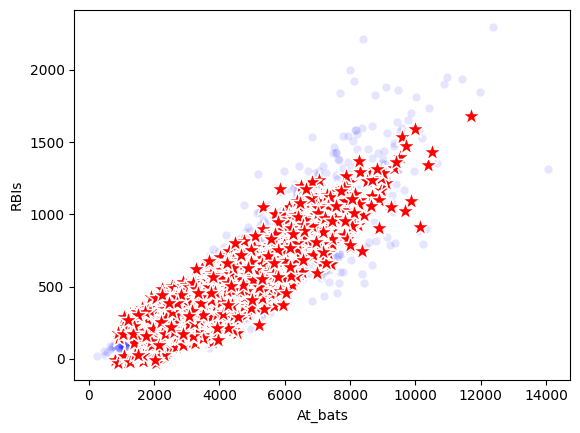

In [17]:
# Listing 11.2 Generating data from left to right
# -----------------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
 
data = fetch_openml('baseball', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Strikeouts'] = df['Strikeouts'].fillna(df['Strikeouts'].median())
 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
 
cat_features = [x for x in df.columns if df[x].nunique() <=10]
num_features = [x for x in df.columns if x not in cat_features]
synth_data = [] 

# Set the left-most column based on its distribution only
feature_0 = df.columns[0]
hist = np.histogram(df[feature_0], density=True)
bin_centers = [(x+y)/2 for x, y in zip(hist[1][:-1], hist[1][1:])]
p = [x/sum(hist[0]) for x in hist[0]]
vals = np.random.choice(bin_centers, p=p, size=len(df)).astype(int)
vals = [x + (((1.0 * np.random.random()) - 0.5) * df[feature_0].std()) 
        for x in vals]
synth_data.append(vals)
synth_cols = [feature_0]

# Loop through the features after the left-most
for col_name in df.columns[1:]:
    print(col_name)
    synth_df = pd.DataFrame(synth_data).T
    synth_df.columns = synth_cols
    
    if col_name in num_features: 
        regr = RandomForestRegressor()

        # Train a Random Forest on real data
        regr.fit(df[synth_cols], df[col_name])

        # Predict on the synthetic data created so far
        pred = regr.predict(synth_df[synth_cols])

        # Add jitter so that there are not only a small number of unique values
        vals = [x + (((1.0 * np.random.random()) - 0.5) * pred.std()) 
                for x in pred]
        synth_data.append(vals)  
        
    if col_name in cat_features:
        clf = RandomForestClassifier()
        clf.fit(df[synth_cols], df[col_name])
        synth_data.append(clf.predict(synth_df[synth_cols]))  
        
    synth_cols.append(col_name)
    
synth_df = pd.DataFrame(synth_data).T
synth_df.columns = synth_cols
        
sns.scatterplot(data=df, x="At_bats", y="RBIs", color='blue', alpha=0.1)
sns.scatterplot(data=synth_df, x="At_bats", y="RBIs", 
                color='red', marker="*", s=200)
plt.show()

In [18]:
# Listing 11.3 Function to generate data left to right using only some previous columns
# -------------------------------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
 
def generate_dataset(df, max_cols_used, use_left):
    feature_0 = df.columns[0]
    hist = np.histogram(df[feature_0], density=True)
    bin_centers = [(x+y)/2 for x, y in zip(hist[1][:-1], hist[1][1:])]
    p = [x/sum(hist[0]) for x in hist[0]]
    vals = np.random.choice(bin_centers, p=p, size=len(df)).astype(int)
    vals = [x + (((1.0 * np.random.random()) - 0.5) * df[feature_0].std()) 
            for x in vals]
    synth_data.append(vals)
    synth_cols = [feature_0]
 
    for col_name in df.columns[1:]:
        print(col_name)
        synth_df = pd.DataFrame(synth_data).T
        synth_df.columns = synth_cols
        if use_left:
            use_synth_cols = synth_cols[:max_cols_used]            
        else:
            use_synth_cols = synth_cols[-max_cols_used:]
 
        if col_name in num_features:
            regr = RandomForestRegressor()
            regr.fit(df[use_synth_cols], df[col_name]) 
            pred = regr.predict(synth_df[use_synth_cols]) 
            vals = [x + (((1.0 * np.random.random()) - 0.5) * pred.std())
                    for x in pred] 
            synth_data.append(vals)  
 
        if col_name in cat_features:
            clf = RandomForestClassifier()
            clf.fit(df[use_synth_cols], df[col_name])
            synth_data.append(clf.predict(synth_df[use_synth_cols]))  
 
        synth_cols.append(col_name)
 
    synth_df = pd.DataFrame(synth_data).T
    synth_df.columns = synth_cols
    return synth_df 
   
synth_df = generate_dataset(df, max_cols_used=2, use_left=False)

Games_played


ValueError: Length mismatch: Expected axis has 17 elements, new values have 1 elements

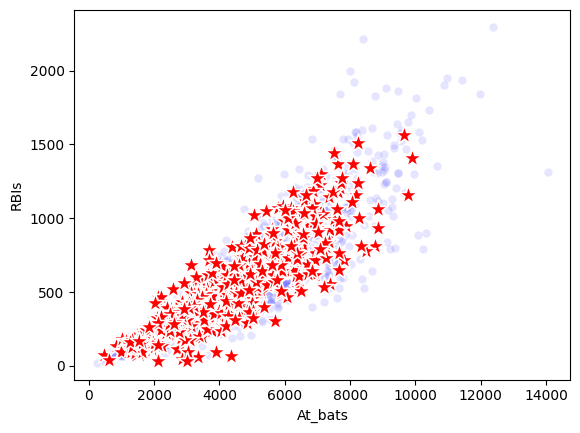

In [20]:
# Listing 11.4 Generating data from a GMM
# ---------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

# Load the data
data = fetch_openml('baseball', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Strikeouts'] = df['Strikeouts'].fillna(df['Strikeouts'].median())
df = pd.get_dummies(df)
 
np.random.seed(0)

# Clean the data of strong outliers
clf_if = IsolationForest()
clf_if.fit(df)
pred = clf_if.decision_function(df)    
trimmed_df = df.loc[np.argsort(pred)[50:]]

# Determine the best number of clusters to use
best_score = np.inf
best_n_clusters = -1
for n_clusters in range(2, 10):
    gmm = GaussianMixture(n_components=n_clusters)
    gmm.fit(trimmed_df)
    score = gmm.bic(trimmed_df)
    if score < best_score:
        best_score = score
        best_n_clusters = n_clusters

# Fit a GMM
gmm = GaussianMixture(n_components=best_n_clusters)
gmm.fit(trimmed_df)

# Use the GMM to generate synthetic data
samples = gmm.sample(n_samples=500)
synth_df = pd.DataFrame(samples[0], columns=df.columns)
 
sns.scatterplot(data=df, x="At_bats", y="RBIs", color='blue', alpha=0.1)
sns.scatterplot(data=synth_df, x="At_bats", y="RBIs", 
                color='red', marker="*", s=200)
plt.show()

In [24]:
# Listing 11.5 Doping using a Random Forest
# -----------------------------------------

import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import random
from scipy import stats
 
np.random.seed(0)

# Collect the data
data = fetch_openml('baseball', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Strikeouts'] = df['Strikeouts'].fillna(df['Strikeouts'].median())
df = pd.get_dummies(df)
df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
 
cat_features = [x for x in df.columns if df[x].nunique() <=10]
num_features = [x for x in df.columns if x not in cat_features]

# Define the minimum and maximum number of features to modify each row
min_cols_per_modification = 1
max_cols_per_modification = 5
doped_df = df.copy().head(20)

# Loop through each row
for i in doped_df.index:

    # Determine the set of columns to modify
    num_cols_modified = -1
    while (num_cols_modified < min_cols_per_modification) or \
      (num_cols_modified > max_cols_per_modification):
        num_cols_modified = int(abs(np.random.laplace(1.0, 10)))
    modified_cols = np.random.choice(df.columns, num_cols_modified, 
                                     replace=False)
 
    for col_name in modified_cols:
        other_cols = df.columns.tolist()
        other_cols.remove(col_name)
        if col_name in num_features: 
            regr = RandomForestRegressor()
            regr.fit(df[other_cols], df[col_name])             
            pred = regr.predict(
               pd.DataFrame(doped_df.iloc[i][other_cols]).T)[0] 
            pred_quantile = stats.percentileofscore(
               df[col_name], pred) // 25
            cur_val = doped_df.loc[i, col_name]
            cur_val_quantile = stats.percentileofscore(
               df[col_name], cur_val) // 25
            q1 = doped_df[col_name].quantile(0.25)
            q2 = doped_df[col_name].quantile(0.5)
            q3 = doped_df[col_name].quantile(0.75)
            quantiles_list = list(range(4))
            np.random.shuffle(quantiles_list)

            # Select a random quartile such that neither the actual nor predicted value is in that quartile
            for q in quantiles_list:
                if q != pred_quantile and q != cur_val_quantile:
                    break
                    
            # Generate a random value within the selected quartile
            doped_df.loc[i, col_name] =\
                ((0.25) * q) + 0.125 + np.random.random()/20